# 📊 因子分析 Pipeline - 使用说明

## ✅ 基本要求（最小输入）

只需要**两列**即可跑通大部分核心功能：

```python
df = pd.DataFrame({
    'your_factor': [...],      # 因子值
    'fwd_ret_1': [...],        # 未来1期收益率（或任何名称的收益率列）
})
```

### 可以直接跑的核心功能：
1. ✅ **IC计算** - `compute_timeseries_ic()`
2. ✅ **分层收益分析** - `quantile_analysis()`
3. ✅ **IC衰减** - `compute_ic_decay()`
4. ✅ **因子半衰期** - `estimate_factor_half_life()`
5. ✅ **IC显著性检验** - `ic_significance_test()`
6. ✅ **微观结构噪音诊断** - `microstructure_noise_diagnostic()`（只需收益率列）
7. ✅ **综合报告** - `comprehensive_factor_report()`（会自动计算所有基础指标）

---

## 📅 需要时间索引的功能

部分功能需要 **DatetimeIndex**（因为涉及时间序列操作）：

```python
df.index = pd.to_datetime(...)  # 设置时间索引
```

需要时间索引的功能：
- `quantile_returns_timeseries()` - 分层收益时间序列
- `compute_factor_autocorrelation()` - 因子自相关（需要shift）
- `compute_quantile_turnover()` - 周转率（需要shift）
- `rolling_ic_analysis()` - 滚动IC
- `intraday_ic_analysis()` - 日内IC分析（还需要提取小时信息）
- 所有涉及时间的可视化

---

## 🎯 快速开始

**最小配置**（90%的功能）：
```python
df = pd.DataFrame({
    'my_factor': factor_values,
    'fwd_ret_1': future_returns
})

# 即可运行
ic_dict = compute_timeseries_ic(df, ['my_factor'], 'fwd_ret_1')
quantile_stats = quantile_analysis(df, 'my_factor', 'fwd_ret_1')
report = comprehensive_factor_report(df, 'my_factor', 'fwd_ret_1')
```

**完整配置**（100%的功能）：
```python
df = pd.DataFrame({
    'my_factor': factor_values,
    'fwd_ret_1': future_returns
})
df.index = pd.to_datetime(timestamps)  # 添加时间索引

# 所有功能都可用
```

---

## ⚠️ 截面IC的重要注意事项

**截面IC需要标准化！** 

当计算跨品种的截面IC时（如多个加密货币），因子值的量纲可能完全不同：
- BTC价格 ~$60,000 vs 小市值币 ~$0.01
- 高流动性币种的订单簿深度远大于低流动性币种

**不标准化的后果**：大市值/高价币会主导IC计算，结果有偏。

**推荐做法**：
```python
# 使用带标准化的截面IC计算
ic_df = compute_cross_sectional_ic_with_norm(
    panel_df, 
    factor_cols, 
    normalize=True,        # 开启标准化
    norm_method='zscore'   # 推荐：zscore、mad（稳健）、rank（消除量纲）
)
```

详见 **Section 4.5: 截面标准化**

---


In [20]:
#数据文件组织结构
#202509文件夹下有每天的数据，而每天的数据有各个symbol的20档挂单数据
#aggtrades下则是各个symbol的aggtrades数据,每一个都是一个symbol一个月的数据
#每一天有些symbol的挂单数据可能有缺失，但最多缺3-4个
import os
os.listdir('/Volumes/hft/binance2/202509')

['2025-09-10',
 '2025-09-11',
 '2025-09-14',
 '2025-09-07',
 '2025-09-27',
 '2025-09-06',
 '2025-09-04',
 '2025-09-28',
 '2025-09-21',
 '2025-09-20',
 '2025-09-05',
 '2025-09-08',
 '2025-09-03',
 '2025-09-13',
 '2025-09-18',
 '2025-09-16',
 '2025-09-24',
 '2025-09-29',
 '2025-09-23',
 '2025-09-30',
 '2025-09-09',
 '2025-09-12',
 '2025-09-19',
 '2025-09-26',
 '2025-09-17',
 '2025-09-15',
 '2025-09-02',
 'aggtrades',
 '2025-09-22',
 '2025-09-25',
 '2025-09-01',
 '._aggtrades',
 'rawdata']

In [21]:
os.listdir('/Volumes/hft/binance2/202509/2025-09-10')[0:3]

['ACX-2025-09-10-2025-09-10 08-00-00.feather',
 'ARK-2025-09-10-2025-09-10 08-00-00.feather',
 'IOST-2025-09-10-2025-09-10 08-00-00.feather']

In [22]:
os.listdir('/Volumes/hft/binance2/202509/aggtrades')[0:3]

['MASKUSDT-aggTrades-2025-09.csv',
 'JASMYUSDT-aggTrades-2025-09.csv',
 'VETUSDT-aggTrades-2025-09.csv']

In [23]:
import numpy as np
import pandas as pd

def merge_trades_depth(
    trades: pd.DataFrame,
    depth: pd.DataFrame,
    *,
    trade_time_col: str = "transact_time",  # trades 的时间列（毫秒）
    depth_time_col: str = "T",              # depth 的时间列（毫秒）
    unit: str = "ms",
    range_policy: str = "overlap",          # "overlap" | "union"
    how: str = "trade_asof",                # "trade_asof" | "depth_asof" | "outer"
    direction: str = "backward",            # asof 方向
    tolerance: str = "1s",                  # asof 最大时间差
    ffill_depth_in_outer: bool = True,      # outer 时是否仅对盘口列 ffill
    staleness_ms: int | None = 500          # 盘口陈旧度上限（毫秒）；None 表示不限制
) -> pd.DataFrame:
    """
    统一时间索引并合并 Binance trades 与 L2 depth。

    - trades 期望列：['agg_trade_id','price','quantity','first_trade_id','last_trade_id',
                     'transact_time','is_buyer_maker', ...]
    - depth  期望列：['T','ap1','av1',...,'bp1','bv1',...]（你的列集也包含 q1/q2/q3）

    返回：DatetimeIndex 的合并 DataFrame。不会对原始成交事件列做 ffill。
    """

    def _ensure_dt_index(df: pd.DataFrame, time_col: str) -> pd.DataFrame:
        if not isinstance(df.index, pd.DatetimeIndex):
            if time_col not in df.columns:
                raise ValueError(f"缺少时间列 {time_col}")
            df = df.copy()
            df.index = pd.to_datetime(df[time_col], unit=unit, errors="coerce")
        if not df.index.is_monotonic_increasing:
            df = df.sort_index()
        return df

    # 1) 统一时间索引 & 升序
    t = _ensure_dt_index(trades, trade_time_col)
    d = _ensure_dt_index(depth,  depth_time_col)

    if t.empty or d.empty:
        raise ValueError("trades 或 depth 为空。")

    # 2) 区间策略：默认 'overlap'（用长适配短 → 取交集）
    t0, t1 = t.index[0], t.index[-1]
    d0, d1 = d.index[0], d.index[-1]
    if range_policy == "overlap":
        start, end = max(t0, d0), min(t1, d1)
        if start > end:
            raise ValueError("trades 与 depth 时间区间无重叠。")
    elif range_policy == "union":
        start, end = min(t0, d0), max(t1, d1)
    else:
        raise ValueError("range_policy 需为 'overlap' 或 'union'")

    t_clip = t.loc[(t.index >= start) & (t.index <= end)].copy()
    d_clip = d.loc[(d.index >= start) & (d.index <= end)].copy()

    # 3) 盘口列识别（只这些允许 ffill）
    depth_cols = []
    for c in d_clip.columns:
        if c == depth_time_col or c.startswith(("ap","av","bp","bv","q")):
            depth_cols.append(c)

    # 4) 三种合并方式
    if how == "trade_asof":
        # 每笔成交贴最近（不晚于成交）的盘口
        # 【修改点】使用更稳健的 reset_index(names=...)
        t_tmp = t_clip.reset_index(names="ts")
        d_tmp = d_clip.reset_index(names="ts")
        out = pd.merge_asof(
            t_tmp, d_tmp, on="ts", direction=direction,
            tolerance=pd.Timedelta(tolerance)
        ).set_index("ts")

    elif how == "depth_asof":
        # 每帧盘口贴最近（不晚于该帧）的成交
        # 【修改点】使用更稳健的 reset_index(names=...)
        t_tmp = t_clip.reset_index(names="ts")
        d_tmp = d_clip.reset_index(names="ts")
        out = pd.merge_asof(
            d_tmp, t_tmp, on="ts", direction=direction,
            tolerance=pd.Timedelta(tolerance)
        ).set_index("ts")

    elif how == "outer":
        # 外连接：只对盘口列可选 ffill（带陈旧度守卫）
        out = t_clip.merge(d_clip, how="outer", left_index=True, right_index=True)
        if ffill_depth_in_outer and depth_cols:
            out[depth_cols] = out[depth_cols].ffill()
    else:
        raise ValueError("how 需为 'trade_asof' | 'depth_asof' | 'outer'")

    # 5) 盘口陈旧度评估与守卫（无论哪种合并，都可启用）
    if "T" in out.columns:
        book_time = pd.to_datetime(out["T"], unit=unit, errors="coerce")
        out["book_age_ms"] = (out.index - book_time).total_seconds() * 1000
        if staleness_ms is not None and depth_cols:
            stale_mask = out["book_age_ms"] > staleness_ms
            out.loc[stale_mask, depth_cols] = np.nan

    return out
dpeth_path = '/Volumes/hft/binance2/202509/2025-09-01/1000CAT-2025-09-01-2025-09-01 08_00_00.feather'
trades_path = '/Volumes/hft/binance2/202509/aggtrades/1000CATUSDT-aggTrades-2025-09.csv'

depth = pd.read_feather(dpeth_path)
trade = pd.read_csv(trades_path)
trade.index = pd.to_datetime(trade['transact_time'], unit='ms')

trade = trade.drop(columns=['transact_time'])
depth = depth.drop(columns=['T'])

#df = merge_trades_depth(trade, depth, tolerance='300ms', staleness_ms=1000)

## 1. 数据加载函数


In [1]:
import numpy as np
import pandas as pd
import os
from glob import glob
from typing import List, Tuple, Dict
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.filterwarnings('ignore')

def load_depth_data(symbol: str, date: str, base_path: str = '/Volumes/hft/binance2/202509') -> pd.DataFrame:
    """
    加载单个symbol单日的盘口数据，确保符合 cancel_metrics.py 的要求
    
    参数:
        symbol: 交易对符号（不带USDT），如 '1000CAT'
        date: 日期字符串，如 '2025-09-01'
        base_path: 数据根目录
    
    返回:
        DataFrame with DatetimeIndex and columns: T,q1,q2,q3,ap1-ap20,av1-av20,bp1-bp20,bv1-bv20
        - Index: DatetimeIndex (cancel_metrics 从这里读取时间)
        - 必须包含列: ap1-ap15, av1-av15, bp1-bp15, bv1-bv15
    """
    # 构造文件路径（根据实际文件命名规则）
    file_pattern = f"{base_path}/{date}/{symbol}-{date}-*.feather"
    files = glob(file_pattern)
    
    if not files:
        raise FileNotFoundError(f"未找到文件: {file_pattern}")
    
    df = pd.read_feather(files[0])
    
    # 确保有时间索引（cancel_metrics 从 index 读取时间）
    if 'T' in df.columns:
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df['T'], unit='ms')
        # 保持 T 列的原始值（毫秒时间戳）
        # 注意：不要删除或修改 T 列！
    else:
        raise ValueError(f"depth数据缺少时间列 'T': {files[0]}")
    
    # 验证必要的列是否存在
    required_cols = [f"ap{i}" for i in range(1, 16)] + [f"av{i}" for i in range(1, 16)] + \
                   [f"bp{i}" for i in range(1, 16)] + [f"bv{i}" for i in range(1, 16)]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"depth数据缺少必要的列: {missing_cols[:5]}... (共{len(missing_cols)}个)")
    
    return df


def load_trades_data(symbol: str, month: str = '2025-09', 
                     base_path: str = '/Volumes/hft/binance2/202509') -> pd.DataFrame:
    """
    加载单个symbol整月的成交数据，确保符合 cancel_metrics.py 的要求
    
    参数:
        symbol: 交易对符号（带USDT），如 '1000CATUSDT'
        month: 月份字符串，如 '2025-09'
        base_path: 数据根目录
    
    返回:
        DataFrame with DatetimeIndex and columns: qty, side, ...
        - Index: DatetimeIndex (cancel_metrics 会从 index 读取时间)
        - 必须包含列: qty (float), side (str: 'buy' or 'sell')
    """
    file_path = f"{base_path}/aggtrades/{symbol}-aggTrades-{month}.csv"
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"未找到文件: {file_path}")
    
    df = pd.read_csv(file_path)
    
    # 统一列名：qty 和 side
    if 'quantity' in df.columns:
        df['qty'] = df['quantity'].astype(float)
    elif 'qty' not in df.columns:
        raise ValueError(f"trades数据缺少数量列 'quantity' 或 'qty': {file_path}")
    
    if 'is_buyer_maker' in df.columns:
        # is_buyer_maker=True表示买方是maker(被动方)，即taker是卖方，对应sell
        df['side'] = df['is_buyer_maker'].map({True: 'sell', False: 'buy'})
    elif 'side' not in df.columns:
        raise ValueError(f"trades数据缺少方向列 'is_buyer_maker' 或 'side': {file_path}")
    
    # 设置时间索引（cancel_metrics 从 index 读取时间）
    if 'transact_time' in df.columns:
        df.index = pd.to_datetime(df['transact_time'], unit='ms')
    else:
        raise ValueError(f"trades数据缺少时间列 'transact_time': {file_path}")
    
    return df


def get_available_symbols_for_date(date: str, base_path: str = '/Volumes/hft/binance2/202509') -> List[str]:
    """
    获取指定日期下有数据的所有symbol
    
    参数:
        date: 日期字符串，如 '2025-09-01'
        base_path: 数据根目录
    
    返回:
        symbol列表（不带USDT）
    """
    date_path = f"{base_path}/{date}"
    if not os.path.exists(date_path):
        return []
    
    files = os.listdir(date_path)
    symbols = []
    for f in files:
        if f.endswith('.feather'):
            # 提取symbol名称（去掉日期和时间部分）
            symbol = f.split('-')[0]
            if symbol not in symbols:
                symbols.append(symbol)
    
    return sorted(symbols)

print("数据加载函数定义完成")


数据加载函数定义完成


## 2. 因子计算与收益率计算


In [16]:
symbol = 'DOT'
date = '2025-09-12'
base_path: str = '/Volumes/hft/binance2/202509'

depth = load_depth_data(symbol, date, base_path)
trades = load_trades_data(f"{symbol}USDT", month='2025-09', base_path=base_path)

# 筛选当日交易数据
start_time = pd.Timestamp(date)
end_time = start_time + pd.Timedelta(days=1)
trades = trades[(trades.index >= start_time) & (trades.index < end_time)]


def add_microsecond_offset_simple(df):
    """为重复的时间戳添加微秒偏移，使索引唯一（简化版）"""
    df = df.copy()
    
    # 为每个重复的时间戳生成一个序号 (0, 1, 2, ...)
    offsets = df.groupby(df.index).cumcount()
    
    # 将序号转换为微秒偏移并加到原索引上
    df.index = df.index + pd.to_timedelta(offsets, unit='us')
    
    return df

# 使用（简单多了！）
depth_unique = add_microsecond_offset_simple(depth)
trades_unique = add_microsecond_offset_simple(trades)

print(f"订单簿索引唯一: {depth_unique.index.is_unique}")
print(f"成交索引唯一: {trades_unique.index.is_unique}")

factors = compute_all_basic_factors(trades_unique, depth_unique, "60s")

订单簿索引唯一: True
成交索引唯一: True


In [17]:
factors.to_csv('basic_factors3.csv',index=False)

DatetimeIndex(['2025-09-10 22:10:00', '2025-09-10 22:11:00',
               '2025-09-10 22:12:00', '2025-09-10 22:13:00',
               '2025-09-10 22:14:00', '2025-09-10 22:15:00',
               '2025-09-10 22:16:00', '2025-09-10 22:17:00',
               '2025-09-10 22:18:00', '2025-09-10 22:19:00',
               '2025-09-10 22:20:00', '2025-09-10 22:21:00',
               '2025-09-10 22:22:00', '2025-09-10 22:23:00',
               '2025-09-10 22:24:00', '2025-09-10 22:25:00',
               '2025-09-10 22:26:00', '2025-09-10 22:27:00',
               '2025-09-10 22:28:00', '2025-09-10 22:29:00',
               '2025-09-10 22:30:00', '2025-09-10 22:31:00',
               '2025-09-10 22:32:00', '2025-09-10 22:33:00',
               '2025-09-10 22:34:00', '2025-09-10 22:35:00',
               '2025-09-10 22:36:00', '2025-09-10 22:37:00',
               '2025-09-10 22:38:00', '2025-09-10 22:39:00',
               '2025-09-10 22:40:00', '2025-09-10 22:41:00',
               '2025-09-

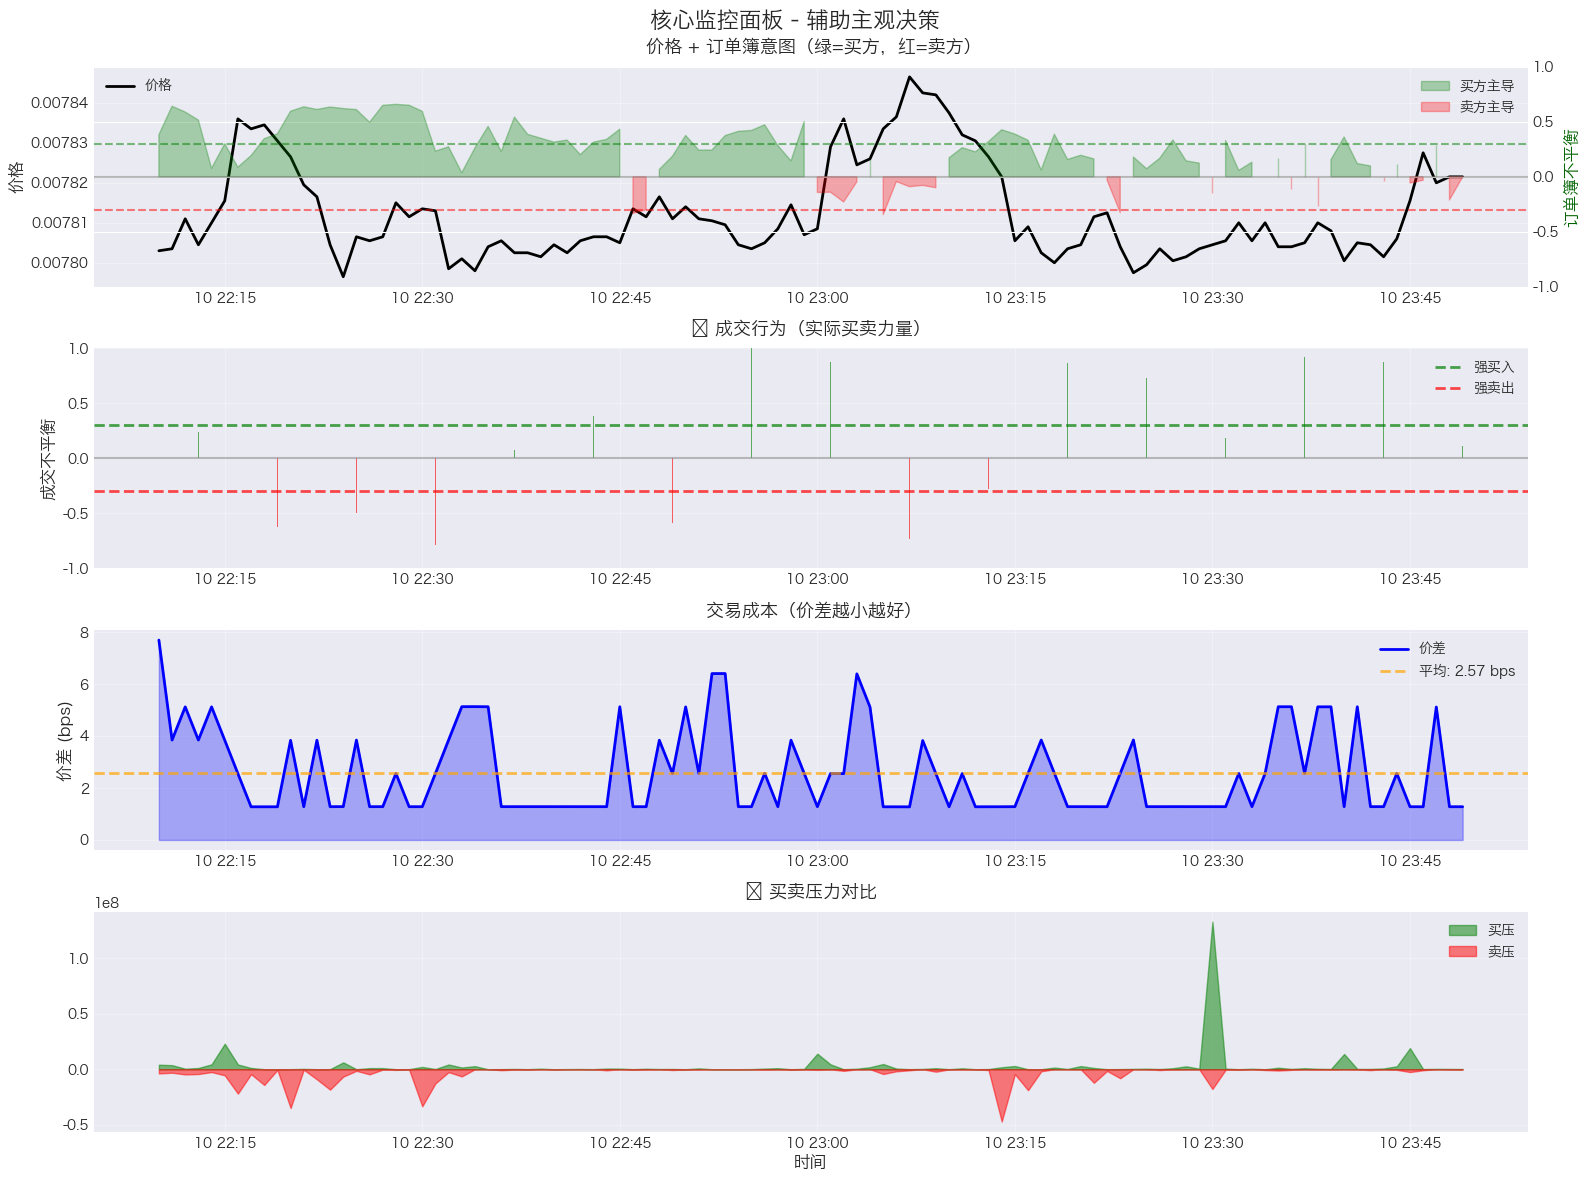


                    📊 当前市场状态

价格: 0.01
价差: 1.28 bps
订单簿: ⚪ 中性 (-0.002)
成交: ⚪ 中性 (0.115)

💡 简单判断:
   ⏸️  市场平衡 → 观望



In [9]:
import factors_visual
importlib.reload(factors_visual)
from factors_visual import plot_core_dashboard
plot_core_dashboard(factors)

## 3. 时序IC计算

时序IC（Time-Series IC）：针对单个symbol，计算因子在时间序列上与未来收益的相关性。
- 适用场景：评估因子在单个标的上的预测能力
- 计算方法：对单个symbol的时间序列数据，计算因子值与未来收益的相关系数


In [3]:
symbol = '1000CAT'
date = '2025-09-10'

def get_basic_factors(symbol, date):
    base_path: str = '/Volumes/hft/binance2/202509'

    depth = load_depth_data(symbol, date, base_path)
    trades = load_trades_data(f"{symbol}USDT", month='2025-09', base_path=base_path)

    # 筛选当日交易数据
    start_time = pd.Timestamp(date)
    end_time = start_time + pd.Timedelta(days=1)
    trades = trades[(trades.index >= start_time) & (trades.index < end_time)]


    def add_microsecond_offset_simple(df):
        """为重复的时间戳添加微秒偏移，使索引唯一（简化版）"""
        df = df.copy()
        
        # 为每个重复的时间戳生成一个序号 (0, 1, 2, ...)
        offsets = df.groupby(df.index).cumcount()
        
        # 将序号转换为微秒偏移并加到原索引上
        df.index = df.index + pd.to_timedelta(offsets, unit='us')
        
        return df

    # 使用（简单多了！）
    depth_unique = add_microsecond_offset_simple(depth)
    trades_unique = add_microsecond_offset_simple(trades)

    print(f"订单簿索引唯一: {depth_unique.index.is_unique}")
    print(f"成交索引唯一: {trades_unique.index.is_unique}")

    factors = compute_all_basic_factors(trades_unique, depth_unique, "60s")
    return factors

In [ ]:
def compute_timeseries_ic(df: pd.DataFrame, 
                          factor_cols: List[str],
                          return_col: str = 'fwd_ret_1',
                          method: str = 'spearman') -> Dict[str, float]:
    """
    计算时序IC：单个symbol的因子与未来收益的时间序列相关性
    
    参数:
        df: 包含因子和收益的DataFrame（单个symbol）
        factor_cols: 因子列名列表
        return_col: 收益率列名
        method: 'spearman' 或 'pearson'
    
    返回:
        字典 {因子名: IC值}
    """
    ic_dict = {}
    
    for factor in factor_cols:
        if factor not in df.columns or return_col not in df.columns:
            ic_dict[factor] = np.nan
            continue
        
        # 去除NaN
        valid_mask = df[[factor, return_col]].notna().all(axis=1)
        if valid_mask.sum() < 10:  # 至少需要10个有效样本
            ic_dict[factor] = np.nan
            continue
        
        factor_vals = df.loc[valid_mask, factor].values
        return_vals = df.loc[valid_mask, return_col].values
        
        # 计算相关系数
        if method == 'spearman':
            corr, _ = spearmanr(factor_vals, return_vals)
        else:
            corr, _ = pearsonr(factor_vals, return_vals)
        
        ic_dict[factor] = corr
    
    return ic_dict

def compute_timeseries_ic_multiday(symbol: str, 
                                    dates: List[str],
                                    factor_cols: List[str],
                                    return_col: str = 'fwd_ret_1',
                                    window_s: float = 1.0,
                                    method: str = 'spearman',
                                    base_path: str = '/Volumes/hft/binance2/202509') -> pd.DataFrame:
    """
    计算单个symbol多日的时序IC
    
    参数:
        symbol: 交易对符号
        dates: 日期列表
        factor_cols: 因子列名列表
        return_col: 收益率列名
        window_s: 时间窗口
        method: 相关系数方法
        base_path: 数据根目录
    
    返回:
        DataFrame，index为日期，columns为各因子的IC
    """
    ic_results = []
    '''
    panel_df = []

    for i in dates:
        if i.endswith('6'):
            continue
        f = get_basic_factors(symbol, i)
        f['symbol'] = i
        panel_df.append(f)
    '''
    for date in dates:
        # 计算该日数据
        df = get_basic_factors(symbol, date)
        
        if df.empty:
            continue
        
        # 计算IC
        ic_dict = compute_timeseries_ic(df, factor_cols, return_col, method)
        ic_dict['date'] = date
        ic_dict['symbol'] = symbol
        ic_results.append(ic_dict)
    
    if not ic_results:
        return pd.DataFrame()
    
    ic_df = pd.DataFrame(ic_results)
    ic_df = ic_df.set_index('date')
    
    return ic_df




print("时序IC计算函数定义完成")


时序IC计算函数定义完成


## 4.5 截面标准化 (Cross-Sectional Normalization)

**为什么需要标准化？**

在计算截面IC时，不同品种的因子值量纲可能完全不同：
- BTC价格 ~$60,000，小市值币 ~$0.01
- 高流动性币种的订单簿深度 >> 低流动性币种
- 未标准化会导致大市值/高价币主导IC计算

**学术标准做法**：
- Alphalens、Barra等主流框架都会在计算截面IC前进行标准化
- 标准化方法：Z-score、Rank、MAD等

下面实现了常用的标准化方法：


In [15]:
def cross_sectional_normalize(panel_df: pd.DataFrame,
                               factor_cols: List[str],
                               method: str = 'zscore',
                               clip_std: float = 3.0,
                               robust: bool = False) -> pd.DataFrame:
    """
    截面标准化：在每个时间点，对不同symbol的因子值进行标准化
    
    参数:
        panel_df: 面板数据，包含多个symbol的因子，需要有symbol列
        factor_cols: 需要标准化的因子列名列表
        method: 标准化方法
            - 'zscore': Z-score标准化 (x - mean) / std
            - 'rank': 排序标准化，转换为[0, 1]区间的排名
            - 'mad': 使用中位数绝对偏差(MAD)的稳健标准化
            - 'demean': 仅去均值，不除以标准差
        clip_std: zscore/mad方法的截断倍数（防止极端值）
        robust: 是否使用稳健统计量（中位数/MAD代替均值/std）
    
    返回:
        标准化后的DataFrame（原地修改）
    """
    df = panel_df.copy()
    
    # 按时间分组进行截面标准化
    for timestamp, group in df.groupby(df.index):
        if len(group) < 3:  # 至少需要3个样本才有意义
            continue
        
        for factor in factor_cols:
            if factor not in df.columns:
                continue
            
            # 获取该时间点的因子值
            factor_vals = group[factor].values
            valid_mask = ~np.isnan(factor_vals)
            
            if valid_mask.sum() < 3:
                continue
            
            valid_vals = factor_vals[valid_mask]

            # 执行标准化
            if method == 'zscore':
                if robust:
                    # 稳健Z-score：使用中位数和MAD
                    center = np.median(valid_vals)
                    mad = np.median(np.abs(valid_vals - center))
                    scale = mad * 1.4826  # MAD到std的转换系数
                else:
                    # 普通Z-score
                    center = np.mean(valid_vals)
                    scale = np.std(valid_vals)
                
                if scale > 1e-8:  # 避免除零
                    normalized = (valid_vals - center) / scale
                    # 截断极端值
                    if clip_std > 0:
                        normalized = np.clip(normalized, -clip_std, clip_std)
                else:
                    normalized = np.zeros_like(valid_vals)
                    
            elif method == 'rank':
                # 排序标准化：转换为[0, 1]区间
                # rankdata返回排名(1到n)，转换为[0, 1]
                from scipy.stats import rankdata
                ranks = rankdata(valid_vals)
                normalized = (ranks - 1) / (len(ranks) - 1) if len(ranks) > 1 else np.zeros_like(valid_vals)
                # 转换为[-0.5, 0.5]以保持零均值
                normalized = normalized - 0.5
                
            elif method == 'mad':
                # MAD标准化（稳健方法）
                center = np.median(valid_vals)
                mad = np.median(np.abs(valid_vals - center))
                
                if mad > 1e-8:
                    normalized = (valid_vals - center) / (mad * 1.4826)
                    if clip_std > 0:
                        normalized = np.clip(normalized, -clip_std, clip_std)
                else:
                    normalized = np.zeros_like(valid_vals)
                    
            elif method == 'demean':
                # 仅去均值
                if robust:
                    center = np.median(valid_vals)
                else:
                    center = np.mean(valid_vals)
                normalized = valid_vals - center
                
            else:
                raise ValueError(f"Unknown normalization method: {method}")
            
            # 写回DataFrame（只更新有效值）
            # 使用布尔索引创建Series，然后更新到df
            
            valid_indices = group.index[valid_mask]
            normalized_series = pd.Series(normalized, index=valid_indices)

            #df.loc[normalized_series.index, factor] = normalized_series.values
            df.loc[timestamp, factor] = normalized_series.values

    
    return df


def cross_sectional_normalize_(
        panel_df: pd.DataFrame,
        factor_cols: List[str],
        method: str = 'zscore',
        clip_std: float = 3.0,
        robust: bool = False
) -> pd.DataFrame:
    """
    截面标准化：在每个时间点，对不同 symbol 的因子值进行标准化

    参数:
        panel_df: 面板数据，index 为日期（可重复），列必须包含 factor_cols
        factor_cols: 需要标准化的因子列名列表
        method: 'zscore'|'rank'|'mad'|'demean'
        clip_std: zscore/mad 截断倍数
        robust: 是否用中位数/MAD 代替均值/标准差

    返回:
        标准化后的 DataFrame（原地修改副本）
    """
    df = panel_df.copy()

    # 按日期分组（index 重复代表不同 symbol）
    for timestamp, group in df.groupby(df.index):
        if len(group) < 3:           # 样本太少无意义
            continue

        # 先拿到本段在原始 df 里的绝对行号（整数数组）
        pos = df.index.get_indexer_for(group.index)   # length = len(group)

        for factor in factor_cols:
            if factor not in df.columns:
                continue

            factor_vals = group[factor].values
            valid_mask = ~np.isnan(factor_vals)
            if valid_mask.sum() < 3:
                continue
            valid_vals = factor_vals[valid_mask]

            # ---------- 标准化逻辑 ----------
            if method == 'zscore':
                center = np.median(valid_vals) if robust else np.mean(valid_vals)
                scale = (np.median(np.abs(valid_vals - center)) * 1.4826) if robust else np.std(valid_vals)
                if scale > 1e-8:
                    normalized = (valid_vals - center) / scale
                    if clip_std > 0:
                        normalized = np.clip(normalized, -clip_std, clip_std)
                else:
                    normalized = np.zeros_like(valid_vals)

            elif method == 'rank':
                from scipy.stats import rankdata
                ranks = rankdata(valid_vals)
                normalized = (ranks - 1) / (len(ranks) - 1) if len(ranks) > 1 else np.zeros_like(valid_vals)
                normalized -= 0.5          # 移到 [-0.5, 0.5]

            elif method == 'mad':
                center = np.median(valid_vals)
                mad = np.median(np.abs(valid_vals - center))
                scale = mad * 1.4826
                if scale > 1e-8:
                    normalized = (valid_vals - center) / scale
                    if clip_std > 0:
                        normalized = np.clip(normalized, -clip_std, clip_std)
                else:
                    normalized = np.zeros_like(valid_vals)

            elif method == 'demean':
                center = np.median(valid_vals) if robust else np.mean(valid_vals)
                normalized = valid_vals - center

            else:
                raise ValueError(f"Unknown normalization method: {method}")

            # ---------- 写回：按位置 ----------
            col_idx = df.columns.get_loc(factor)
            idx_to_write = pos[valid_mask]          # 整数数组，长度 == normalized
            df.iloc[idx_to_write, col_idx] = normalized

    return df

def compute_cross_sectional_ic_with_norm(panel_df: pd.DataFrame,
                                          factor_cols: List[str],
                                          return_col: str = 'fwd_ret_1',
                                          method: str = 'spearman',
                                          min_symbols: int = 5,
                                          normalize: bool = True,
                                          norm_method: str = 'zscore',
                                          norm_clip: float = 3.0) -> pd.DataFrame:
    """
    计算截面IC（带可选的标准化预处理）
    
    参数:
        panel_df: 面板数据
        factor_cols: 因子列名列表
        return_col: 收益率列名
        method: 相关系数方法 ('spearman' 或 'pearson')
        min_symbols: 每个时间点最少symbol数
        normalize: 是否先进行截面标准化（强烈推荐True）
        norm_method: 标准化方法 ('zscore', 'rank', 'mad', 'demean')
        norm_clip: 标准化截断倍数
    
    返回:
        DataFrame，index为时间，columns为各因子的IC
    """
    df = panel_df.copy()
    
    # 标准化处理
    if normalize:
        df = cross_sectional_normalize(
            df, 
            factor_cols, 
            method=norm_method, 
            clip_std=norm_clip
        )
    
    # 调用原始IC计算函数
    ic_results = []
    
    for timestamp, group in df.groupby(df.index):
        if len(group) < min_symbols:
            continue
        
        ic_dict = {'timestamp': timestamp}
        
        for factor in factor_cols:
            if factor not in group.columns or return_col not in group.columns:
                ic_dict[factor] = np.nan
                continue
            
            valid_mask = group[[factor, return_col]].notna().all(axis=1)
            if valid_mask.sum() < min_symbols:
                ic_dict[factor] = np.nan
                continue
            
            factor_vals = group.loc[valid_mask, factor].values
            return_vals = group.loc[valid_mask, return_col].values
            
            try:
                if method == 'spearman':
                    from scipy.stats import spearmanr
                    corr, _ = spearmanr(factor_vals, return_vals)
                else:
                    from scipy.stats import pearsonr
                    corr, _ = pearsonr(factor_vals, return_vals)
                ic_dict[factor] = corr
            except:
                ic_dict[factor] = np.nan
        
        ic_results.append(ic_dict)
    
    if not ic_results:
        return pd.DataFrame()
    
    return pd.DataFrame(ic_results).set_index('timestamp')


def compare_normalization_methods(panel_df: pd.DataFrame,
                                    factor_cols: List[str],
                                    return_col: str = 'fwd_ret_1') -> pd.DataFrame:
    """
    比较不同标准化方法对IC的影响
    
    参数:
        panel_df: 面板数据
        factor_cols: 因子列表
        return_col: 收益率列名
    
    返回:
        各因子在不同标准化方法下的IC均值对比
    """
    methods = ['none', 'zscore', 'rank', 'mad', 'demean']
    results = []
    
    for method in methods:
        if method == 'none':
            ic_df = compute_cross_sectional_ic(
                panel_df, factor_cols, return_col, min_symbols=3
            )
            method_name = 'No Normalization'
        else:
            ic_df = compute_cross_sectional_ic_with_norm(
                panel_df, factor_cols, return_col, 
                normalize=True, norm_method=method, min_symbols=3
            )
            method_name = method.upper()
        
        if not ic_df.empty:
            for factor in factor_cols:
                if factor in ic_df.columns:
                    ic_mean = ic_df[factor].mean()
                    ic_std = ic_df[factor].std()
                    ic_ir = ic_mean / ic_std if ic_std > 0 else np.nan
                    
                    results.append({
                        'Factor': factor,
                        'Method': method_name,
                        'IC_Mean': ic_mean,
                        'IC_Std': ic_std,
                        'IC_IR': ic_ir
                    })
    
    comparison_df = pd.DataFrame(results)
    
    # 透视表格式
    if not comparison_df.empty:
        pivot_ic = comparison_df.pivot(index='Factor', columns='Method', values='IC_Mean')
        pivot_ir = comparison_df.pivot(index='Factor', columns='Method', values='IC_IR')
        
        print("=" * 80)
        print("IC均值对比 (不同标准化方法)")
        print("=" * 80)
        print(pivot_ic.round(4))
        print("\n" + "=" * 80)
        print("IC信息比率(IR)对比 (不同标准化方法)")
        print("=" * 80)
        print(pivot_ir.round(4))
    
    return comparison_df


print("截面标准化函数定义完成")


截面标准化函数定义完成


### 使用示例：截面标准化对比

```python
# 准备面板数据
panel_df = prepare_panel_data(
    symbols=['BTC', 'ETH', 'DOGE'], 
    date='2025-09-01', 
    window_s=60
)

# 方法1：不标准化（可能被大市值币主导）
ic_raw = compute_cross_sectional_ic(panel_df, factor_cols, min_symbols=3)

# 方法2：Z-score标准化（推荐）
ic_norm = compute_cross_sectional_ic_with_norm(
    panel_df, factor_cols, 
    normalize=True, 
    norm_method='zscore'
)

# 方法3：比较所有标准化方法
comparison = compare_normalization_methods(panel_df, factor_cols)
```

**推荐用法**：
- 默认使用 `zscore` 标准化
- 如果数据有极端值，使用 `mad`（稳健方法）
- 如果想完全消除量纲影响，使用 `rank`


In [16]:
def compute_cross_sectional_ic(panel_df: pd.DataFrame,
                                factor_cols: List[str],
                                return_col: str = 'fwd_ret_1',
                                method: str = 'spearman',
                                min_symbols: int = 5) -> pd.DataFrame:
    """
    计算截面IC：在每个时间点，不同symbol的因子与收益的截面相关性
    
    参数:
        panel_df: 面板数据，包含多个symbol的因子和收益，需要有symbol列
        factor_cols: 因子列名列表
        return_col: 收益率列名
        method: 'spearman' 或 'pearson'
        min_symbols: 每个时间点最少需要的symbol数量
    
    返回:
        DataFrame，index为时间，columns为各因子的IC
    """
    ic_results = []
    
    # 按时间分组
    for timestamp, group in panel_df.groupby(panel_df.index):
        if len(group) < min_symbols:
            continue
        
        ic_dict = {'timestamp': timestamp}
        
        for factor in factor_cols:
            if factor not in group.columns or return_col not in group.columns:
                ic_dict[factor] = np.nan
                continue
            
            # 去除NaN
            valid_mask = group[[factor, return_col]].notna().all(axis=1)
            if valid_mask.sum() < min_symbols:
                ic_dict[factor] = np.nan
                continue
            
            factor_vals = group.loc[valid_mask, factor].values
            return_vals = group.loc[valid_mask, return_col].values
            
            # 计算相关系数
            try:
                if method == 'spearman':
                    corr, _ = spearmanr(factor_vals, return_vals)
                else:
                    corr, _ = pearsonr(factor_vals, return_vals)
                ic_dict[factor] = corr
            except:
                ic_dict[factor] = np.nan
        
        ic_results.append(ic_dict)
    
    if not ic_results:
        return pd.DataFrame()
    
    ic_df = pd.DataFrame(ic_results)
    ic_df = ic_df.set_index('timestamp')
    
    return ic_df

def prepare_panel_data(symbols: List[str],
                       date: str,
                       window_s: float = 1.0,
                       horizons: List[int] = [1, 5, 10],
                       base_path: str = '/Volumes/hft/binance2/202509',
                       align_timestamps: bool = True,
                       freq: str = None) -> pd.DataFrame:
    """
    准备面板数据：多个symbol的因子和收益率
    
    参数:
        symbols: symbol列表
        date: 日期
        window_s: 时间窗口
        horizons: 收益率向前看周期
        base_path: 数据根目录
        align_timestamps: 是否对齐时间戳到统一网格
        freq: 对齐频率（如'1min', '5S'等），如果为None则自动根据window_s推断
    
    返回:
        合并后的DataFrame，包含所有symbol的数据
        - 如果 align_timestamps=True，则所有symbol在相同时间点都有数据（通过ffill填充）
        - 如果 align_timestamps=False，则直接concat（可能导致每个时间点symbol数量不足）
    """
    all_dfs = []
    
    for symbol in symbols:
        df = prepare_factor_return_data(symbol, date, window_s, horizons, base_path)
        if not df.empty:
            all_dfs.append(df)
    
    if not all_dfs:
        return pd.DataFrame()
    
    if not align_timestamps:
        # 旧逻辑：直接拼接（会导致时间戳不对齐）
        panel_df = pd.concat(all_dfs, axis=0)
        return panel_df
    
    # 新逻辑：对齐到统一时间网格
    
    # 1. 确定统一的时间范围
    start_time = min(df.index.min() for df in all_dfs)
    end_time = max(df.index.max() for df in all_dfs)
    
    # 2. 推断频率
    if freq is None:
        if window_s < 1:
            freq = f'{int(window_s * 1000)}ms'
        elif window_s < 60:
            freq = f'{int(window_s)}S'
        else:
            freq = f'{int(window_s / 60)}min'
    
    # 3. 创建统一时间索引
    common_index = pd.date_range(start=start_time, end=end_time, freq=freq)
    
    # 4. 对齐每个symbol到统一时间网格
    aligned_dfs = []
    for df in all_dfs:
        # reindex到统一时间网格，使用ffill填充
        df_aligned = df.reindex(common_index, method='ffill', limit=10)  # limit防止过度填充
        aligned_dfs.append(df_aligned)
    
    # 5. 拼接
    panel_df = pd.concat(aligned_dfs, axis=0)
    
    # 6. 去除完全是NaN的行（即没有任何symbol数据的时间点）
    panel_df = panel_df.dropna(how='all', subset=[col for col in panel_df.columns if col != 'symbol'])
    
    return panel_df

def compute_cross_sectional_ic_multiday(symbols: List[str],
                                         dates: List[str],
                                         factor_cols: List[str],
                                         return_col: str = 'fwd_ret_1',
                                         window_s: float = 1.0,
                                         method: str = 'spearman',
                                         min_symbols: int = 5,
                                         base_path: str = '/Volumes/hft/binance2/202509') -> pd.DataFrame:
    """
    计算多日的截面IC
    
    参数:
        symbols: symbol列表
        dates: 日期列表
        factor_cols: 因子列名列表
        return_col: 收益率列名
        window_s: 时间窗口
        method: 相关系数方法
        min_symbols: 每个时间点最少需要的symbol数量
        base_path: 数据根目录
    
    返回:
        DataFrame，包含所有时间点的截面IC
    """
    all_ics = []
    
    for date in dates:
        print(f"处理日期: {date}")
        # 准备该日所有symbol的数据
        panel_df = prepare_panel_data(symbols, date, window_s=window_s, base_path=base_path)
        
        if panel_df.empty:
            continue
        
        # 计算截面IC
        ic_df = compute_cross_sectional_ic(panel_df, factor_cols, return_col, method, min_symbols)
        
        if not ic_df.empty:
            ic_df['date'] = date
            all_ics.append(ic_df)
    
    if not all_ics:
        return pd.DataFrame()
    
    result = pd.concat(all_ics, axis=0)
    return result

print("截面IC计算函数定义完成")


截面IC计算函数定义完成


## 5. IC统计分析函数


In [17]:
def ic_summary_statistics(ic_df: pd.DataFrame, factor_cols: List[str]) -> pd.DataFrame:
    """
    计算IC的汇总统计
    
    参数:
        ic_df: IC时间序列DataFrame
        factor_cols: 因子列名列表
    
    返回:
        统计汇总DataFrame
    """
    stats = []
    
    for factor in factor_cols:
        if factor not in ic_df.columns:
            continue
        
        ic_series = ic_df[factor].dropna()
        
        if len(ic_series) == 0:
            continue
        
        stat = {
            'factor': factor,
            'IC_mean': ic_series.mean(),
            'IC_std': ic_series.std(),
            'IC_IR': ic_series.mean() / ic_series.std() if ic_series.std() > 0 else np.nan,
            'IC_positive_rate': (ic_series > 0).mean(),
            'IC_abs_mean': ic_series.abs().mean(),
            'IC_min': ic_series.min(),
            'IC_max': ic_series.max(),
            'IC_median': ic_series.median(),
            'n_samples': len(ic_series)
        }
        stats.append(stat)
    
    if not stats:
        return pd.DataFrame()
    
    return pd.DataFrame(stats).set_index('factor')

def plot_ic_timeseries(ic_df: pd.DataFrame, factor_cols: List[str], title: str = "IC时间序列"):
    """
    绘制IC时间序列图
    
    参数:
        ic_df: IC时间序列DataFrame
        factor_cols: 要绘制的因子列表
        title: 图标题
    """
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(len(factor_cols), 1, figsize=(14, 4*len(factor_cols)))
    
    if len(factor_cols) == 1:
        axes = [axes]
    
    for ax, factor in zip(axes, factor_cols):
        if factor in ic_df.columns:
            ic_series = ic_df[factor].dropna()
            ax.plot(ic_series.index, ic_series.values, linewidth=1, alpha=0.7)
            ax.axhline(y=0, color='r', linestyle='--', alpha=0.5)
            ax.axhline(y=ic_series.mean(), color='g', linestyle='--', alpha=0.5, 
                      label=f'Mean={ic_series.mean():.4f}')
            ax.set_title(f'{title} - {factor}')
            ax.set_ylabel('IC')
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_ic_distribution(ic_df: pd.DataFrame, factor_cols: List[str], title: str = "IC分布"):
    """
    绘制IC分布图
    
    参数:
        ic_df: IC时间序列DataFrame
        factor_cols: 要绘制的因子列表
        title: 图标题
    """
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, len(factor_cols), figsize=(5*len(factor_cols), 4))
    
    if len(factor_cols) == 1:
        axes = [axes]
    
    for ax, factor in zip(axes, factor_cols):
        if factor in ic_df.columns:
            ic_series = ic_df[factor].dropna()
            ax.hist(ic_series.values, bins=30, alpha=0.7, edgecolor='black')
            ax.axvline(x=0, color='r', linestyle='--', alpha=0.5)
            ax.axvline(x=ic_series.mean(), color='g', linestyle='--', alpha=0.5, 
                      label=f'Mean={ic_series.mean():.4f}')
            ax.set_title(f'{title} - {factor}')
            ax.set_xlabel('IC')
            ax.set_ylabel('频数')
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("IC统计分析函数定义完成")


IC统计分析函数定义完成


## 6. 使用示例

### 6.1 时序IC示例


In [10]:
r1.head().columns

Index(['start_time', 'duration_s', 'C_A', 'C_B', 'E_A', 'E_B', 'A_A', 'A_B',
       'DepthTime_A', 'DepthTime_B', 'CR_ask', 'CR_bid', 'CAR_ask', 'CAR_bid',
       'hazard_ask', 'hazard_bid', 'NetOFI', 'label', 'lvl_can_A', 'lvl_can_B',
       'lvl_add_A', 'lvl_add_B', 'mid_price', 'symbol'],
      dtype='object')

In [104]:
import importlib
import basic_factors
importlib.reload(basic_factors)
from basic_factors import compute_all_basic_factors
from factors_mining import compute_aggressiveness_factors

In [108]:
symbol = 'AXS'
date = '2025-09-01'

def get_basic_factors(symbol, date):
    base_path: str = '/Volumes/hftzhitai/binance/202509'

    depth = load_depth_data(symbol, date, base_path)
    trades = load_trades_data(f"{symbol}USDT", month='2025-09', base_path=base_path)

    # 筛选当日交易数据
    start_time = pd.Timestamp(date)
    end_time = start_time + pd.Timedelta(days=1)
    trades = trades[(trades.index >= start_time) & (trades.index < end_time)]


    def add_microsecond_offset_simple(df):
        """为重复的时间戳添加微秒偏移，使索引唯一（简化版）"""
        df = df.copy()
        
        # 为每个重复的时间戳生成一个序号 (0, 1, 2, ...)
        offsets = df.groupby(df.index).cumcount()
        
        # 将序号转换为微秒偏移并加到原索引上
        df.index = df.index + pd.to_timedelta(offsets, unit='us')
        
        return df

    # 使用（简单多了！）
    depth_unique = add_microsecond_offset_simple(depth)
    trades_unique = add_microsecond_offset_simple(trades)

    print(f"订单簿索引唯一: {depth_unique.index.is_unique}")
    print(f"成交索引唯一: {trades_unique.index.is_unique}")
    print(depth_unique.columns)
    factors = compute_all_basic_factors(trades_unique, depth_unique, "60s")
    #factors = compute_aggressiveness_factors(depth_unique, trades_unique, tau=60)
    return factors

get_basic_factors(symbol, date)

订单簿索引唯一: True
成交索引唯一: True
Index(['T', 'q1', 'q2', 'q3', 'ap1', 'av1', 'ap2', 'av2', 'ap3', 'av3', 'ap4',
       'av4', 'ap5', 'av5', 'ap6', 'av6', 'ap7', 'av7', 'ap8', 'av8', 'ap9',
       'av9', 'ap10', 'av10', 'ap11', 'av11', 'ap12', 'av12', 'ap13', 'av13',
       'ap14', 'av14', 'ap15', 'av15', 'ap16', 'av16', 'ap17', 'av17', 'ap18',
       'av18', 'ap19', 'av19', 'ap20', 'av20', 'bp1', 'bv1', 'bp2', 'bv2',
       'bp3', 'bv3', 'bp4', 'bv4', 'bp5', 'bv5', 'bp6', 'bv6', 'bp7', 'bv7',
       'bp8', 'bv8', 'bp9', 'bv9', 'bp10', 'bv10', 'bp11', 'bv11', 'bp12',
       'bv12', 'bp13', 'bv13', 'bp14', 'bv14', 'bp15', 'bv15', 'bp16', 'bv16',
       'bp17', 'bv17', 'bp18', 'bv18', 'bp19', 'bv19', 'bp20', 'bv20'],
      dtype='object')


,buy_volume,sell_volume,buy_count,sell_count,total_volume,total_count,vwap,trade_imbalance,avg_trade_size,buy_avg_size,...,size_max,size_p25,size_p50,size_p75,large_trade_ratio,arrival_rate,toxicity,ret_1,ret_5,ret_10
2025-09-01 00:01:00,57899.0,56269.0,112,68,114168.0,180,2.496587,0.014277,634.266667,516.955357,...,6138.0,22.00,70.0,967.75,0.205556,3.000000,0.002429,-0.002799,0.001200,-0.010798
2025-09-01 00:02:00,90209.0,218850.0,179,191,309059.0,370,2.481065,-0.416234,835.294595,503.960894,...,8301.0,28.25,168.5,997.50,0.167568,6.166667,0.003416,-0.006818,0.005615,-0.006417
2025-09-01 00:03:00,85710.0,135053.0,141,142,220763.0,283,2.473819,-0.223511,780.081272,607.872340,...,6058.0,34.00,276.0,1033.50,0.166078,4.716667,0.002886,0.002827,0.018171,-0.003634
2025-09-01 00:04:00,29202.0,33126.0,47,72,62328.0,119,2.482859,-0.062957,523.764706,621.319149,...,5369.0,16.50,119.0,637.50,0.159664,1.983333,0.002087,-0.001208,0.000805,-0.006040
2025-09-01 00:05:00,153627.0,80274.0,158,131,233901.0,289,2.495363,0.313607,809.346021,972.322785,...,6418.0,61.00,371.0,1004.00,0.162630,4.816667,0.002618,0.009272,-0.004435,-0.006853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-01 23:45:00,15529.0,3711.0,26,53,19240.0,79,2.326459,0.614241,243.544304,597.269231,...,3276.0,3.00,7.0,56.50,0.126582,1.316667,0.000705,0.002152,-0.000430,-0.001291
2025-09-01 23:46:00,12338.0,12922.0,19,55,25260.0,74,2.331784,-0.023120,341.351351,649.368421,...,3087.0,6.00,16.5,334.50,0.216216,1.233333,0.001024,0.000859,-0.002147,-0.003006
2025-09-01 23:47:00,10982.0,8922.0,15,50,19904.0,65,2.328558,0.103497,306.215385,732.133333,...,3592.0,5.00,9.0,234.00,0.153846,1.083333,0.000926,-0.000858,-0.003862,-0.003004
2025-09-01 23:48:00,12142.0,14830.0,6,54,26972.0,60,2.325133,-0.099659,449.533333,2023.666667,...,5355.0,4.00,7.5,63.75,0.183333,1.000000,0.001337,-0.002147,-0.003006,-0.002147


In [12]:
factors_ret = ['ret_1', 'ret_5','ret_10']

In [112]:
factors_col = ['buy_volume', 'sell_volume', 'buy_count', 'sell_count', 'total_volume',
       'total_count', 'vwap', 'trade_imbalance', 'avg_trade_size',
       'buy_avg_size', 'sell_avg_size', 'total_bid_vol', 'total_ask_vol',
       'lob_imb', 'wmid', 'mid', 'spread', 'spread_bps', 'ask_avg_price_5',
       'bid_avg_price_5', 'tier1_imb', 'tier2_imb', 'tier3_imb', 'tier4_imb',
       'buy_pressure', 'sell_pressure', 'net_pressure', 'buy_intensity',
       'sell_intensity', 'intensity_ratio', 'dominant_side', 'size_mean',
       'size_std', 'size_max', 'size_p25', 'size_p50', 'size_p75',
       'large_trade_ratio', 'arrival_rate', 'toxicity']

In [118]:
# 时序IC示例：计算单个symbol的时序IC

# 定义要测试的因子
factor_cols = factors_col

# 选择一个symbol和日期范围
test_symbol = 'ZRX'
test_dates = ['2025-09-01', '2025-09-02', '2025-09-03']  # 可以扩展更多日期

print(f"计算 {test_symbol} 的时序IC...")
print(f"测试日期: {test_dates}")
print(f"测试因子: {factor_cols}")
factors = get_basic_factors(test_symbol, '2025-09-01')
# 方法1：单日时序IC
print("\n=== 单日时序IC示例 ===")
if not factors.empty:
    ic_single = compute_timeseries_ic(factors, factor_cols, return_col='ret_1')
    print(f"\n{test_dates[0]} 的时序IC:")
    for factor, ic_val in ic_single.items():
        print(f"  {factor:15s}: {ic_val:7.4f}")
else:
    print(f"未能加载 {test_symbol} {test_dates[0]} 的数据")

# 方法2：多日时序IC
'''
print("\n=== 多日时序IC示例 ===")
ic_multiday = compute_timeseries_ic_multiday(
    symbol=test_symbol,
    dates=test_dates,
    factor_cols=factor_cols,
    return_col='ret_1',
    window_s=60
)

if not ic_multiday.empty:
    print(f"\n多日时序IC结果:")
    print(ic_multiday[factor_cols].round(4))
    
    # 统计分析
    print("\n时序IC统计汇总:")
    summary = ic_summary_statistics(ic_multiday, factor_cols)
    print(summary.round(4))
else:
    print("未能计算多日时序IC")
'''


计算 ZRX 的时序IC...
测试日期: ['2025-09-01', '2025-09-02', '2025-09-03']
测试因子: ['buy_volume', 'sell_volume', 'buy_count', 'sell_count', 'total_volume', 'total_count', 'vwap', 'trade_imbalance', 'avg_trade_size', 'buy_avg_size', 'sell_avg_size', 'total_bid_vol', 'total_ask_vol', 'lob_imb', 'wmid', 'mid', 'spread', 'spread_bps', 'ask_avg_price_5', 'bid_avg_price_5', 'tier1_imb', 'tier2_imb', 'tier3_imb', 'tier4_imb', 'buy_pressure', 'sell_pressure', 'net_pressure', 'buy_intensity', 'sell_intensity', 'intensity_ratio', 'dominant_side', 'size_mean', 'size_std', 'size_max', 'size_p25', 'size_p50', 'size_p75', 'large_trade_ratio', 'arrival_rate', 'toxicity']
订单簿索引唯一: True
成交索引唯一: True
Index(['T', 'q1', 'q2', 'q3', 'ap1', 'av1', 'ap2', 'av2', 'ap3', 'av3', 'ap4',
       'av4', 'ap5', 'av5', 'ap6', 'av6', 'ap7', 'av7', 'ap8', 'av8', 'ap9',
       'av9', 'ap10', 'av10', 'ap11', 'av11', 'ap12', 'av12', 'ap13', 'av13',
       'ap14', 'av14', 'ap15', 'av15', 'ap16', 'av16', 'ap17', 'av17', 'ap18',
       

'\nprint("\n=== 多日时序IC示例 ===")\nic_multiday = compute_timeseries_ic_multiday(\n    symbol=test_symbol,\n    dates=test_dates,\n    factor_cols=factor_cols,\n    return_col=\'ret_1\',\n    window_s=60\n)\n\nif not ic_multiday.empty:\n    print(f"\n多日时序IC结果:")\n    print(ic_multiday[factor_cols].round(4))\n    \n    # 统计分析\n    print("\n时序IC统计汇总:")\n    summary = ic_summary_statistics(ic_multiday, factor_cols)\n    print(summary.round(4))\nelse:\n    print("未能计算多日时序IC")\n'

In [110]:
factors

,buy_volume,sell_volume,buy_count,sell_count,total_volume,total_count,vwap,trade_imbalance,avg_trade_size,buy_avg_size,...,size_max,size_p25,size_p50,size_p75,large_trade_ratio,arrival_rate,toxicity,ret_1,ret_5,ret_10
2025-09-01 00:01:00,609318.0,439961.0,16,12,1049279.0,28,0.007677,0.161403,37474.250000,38082.375000,...,166780.0,3369.25,19942.0,66952.00,0.142857,0.466667,0.001688,0.000260,-0.001432,-0.001302
2025-09-01 00:02:00,158848.0,351027.0,16,11,509875.0,27,0.007679,-0.376914,18884.259259,9928.000000,...,132740.0,2149.50,6785.0,17260.00,0.148148,0.450000,0.000970,0.000000,-0.000065,-0.002083
2025-09-01 00:03:00,38845.0,266106.0,14,19,304951.0,33,0.007681,-0.745238,9240.939394,2774.642857,...,73194.0,1085.00,2149.0,6718.00,0.121212,0.550000,0.000468,-0.000651,0.000130,-0.001302
2025-09-01 00:04:00,193057.0,2066878.0,21,37,2259935.0,58,0.007666,-0.829148,38964.396552,9193.190476,...,288726.0,2371.25,10809.5,50024.25,0.137931,0.966667,0.001919,-0.002214,0.000521,-0.000521
2025-09-01 00:05:00,2153454.0,1449514.0,91,44,3602968.0,135,0.007655,0.195378,26688.651852,23664.329670,...,367494.0,2189.00,8314.0,27016.00,0.155556,2.250000,0.000922,0.001175,0.001828,0.000261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-01 23:45:00,1272488.0,77348.0,25,10,1349836.0,35,0.007067,0.885396,38566.742857,50899.520000,...,681631.0,2229.50,5620.0,35709.50,0.114286,0.583333,0.001777,0.002478,-0.001133,-0.004107
2025-09-01 23:46:00,525766.0,2663325.0,34,37,3189091.0,71,0.007093,-0.670272,44916.774648,15463.705882,...,439372.0,2333.50,8153.0,30050.50,0.140845,1.183333,0.002088,0.000283,-0.004167,-0.006145
2025-09-01 23:47:00,955818.0,359514.0,27,19,1315332.0,46,0.007076,0.453349,28594.173913,35400.666667,...,216706.0,4116.25,20765.0,27632.00,0.152174,0.766667,0.001731,-0.000494,-0.006143,-0.007273
2025-09-01 23:48:00,1338899.0,679998.0,8,25,2018897.0,33,0.007065,0.326367,61178.696970,167362.374998,...,1183193.0,2335.00,12397.0,43592.00,0.060606,0.550000,0.005032,-0.002331,-0.006499,-0.005369


In [31]:
all_ic = []
date = '2025-09-01'
symbols = get_available_symbols_for_date(date)[:10]
for sym in symbols:
    factors = get_basic_factors(sym, date)
    ic_single = compute_timeseries_ic(factors, factor_cols, return_col='ret_1')
    ic_single = pd.Series(ic_single, name=sym)
    all_ic.append(ic_single)
all_ic = pd.DataFrame(all_ic)

订单簿索引唯一: True
成交索引唯一: True
订单簿索引唯一: True
成交索引唯一: True
订单簿索引唯一: True
成交索引唯一: True
订单簿索引唯一: True
成交索引唯一: True
订单簿索引唯一: True
成交索引唯一: True
订单簿索引唯一: True
成交索引唯一: True
订单簿索引唯一: True
成交索引唯一: True
订单簿索引唯一: True
成交索引唯一: True
订单簿索引唯一: True
成交索引唯一: True
订单簿索引唯一: True
成交索引唯一: True


In [33]:
all_ic.T

,1000000MOG,1000CAT,1000RATS,ACX,AKT,ALGO,ALT,ARK,AXS,BAT
buy_volume,0.288326,0.279390,0.352468,0.378498,0.332153,0.299741,0.289929,0.321085,0.281625,0.415663
sell_volume,-0.248947,-0.336802,-0.353471,-0.431384,-0.382240,-0.249222,-0.269238,-0.284820,-0.325936,-0.351549
buy_count,0.460089,0.292430,0.278846,0.314074,0.209532,0.209688,0.159863,0.337595,0.255927,0.145884
sell_count,-0.417543,-0.338743,-0.257810,-0.383583,-0.288533,-0.143786,-0.217435,-0.236869,-0.166439,-0.254663
total_volume,0.007138,-0.010101,0.008888,-0.023204,-0.016427,0.045229,0.012832,0.022374,-0.042836,0.051312
total_count,0.020692,-0.038110,0.002108,-0.006004,-0.017503,0.011389,0.032289,0.043796,-0.001408,0.038950
vwap,0.006150,0.004970,0.025364,0.004810,-0.002410,-0.013030,-0.009736,-0.029291,0.016644,0.005905
trade_imbalance,0.499688,0.543799,0.611294,0.622075,0.566452,0.522255,0.518953,0.495678,0.622271,0.614891
avg_trade_size,-0.006917,0.018683,0.011207,-0.015390,-0.008116,0.041896,-0.028662,0.006331,-0.058553,0.023401
buy_avg_size,0.085035,0.164469,0.318796,0.319474,0.347663,0.242065,0.155739,0.198542,0.180557,0.297109


In [29]:
pd.Series(ic_single)

buy_volume           0.279390
sell_volume         -0.336802
buy_count            0.292430
sell_count          -0.338743
total_volume        -0.010101
total_count         -0.038110
vwap                 0.004970
trade_imbalance      0.543799
avg_trade_size       0.018683
buy_avg_size         0.164469
sell_avg_size       -0.208182
total_bid_vol       -0.003859
total_ask_vol       -0.006051
lob_imb             -0.003275
wmid                -0.029361
mid                 -0.029329
spread              -0.024754
spread_bps           0.007050
ask_avg_price_5     -0.029038
bid_avg_price_5     -0.029074
tier1_imb            0.030972
tier2_imb           -0.014296
tier3_imb            0.003736
tier4_imb            0.004762
buy_pressure         0.305446
sell_pressure       -0.355115
net_pressure         0.564934
buy_intensity        0.295566
sell_intensity      -0.351443
intensity_ratio      0.592233
dominant_side        0.526838
size_mean            0.018683
size_std             0.003416
size_max  

In [34]:
summary

,IC_mean,IC_std,IC_IR,IC_positive_rate,IC_abs_mean,IC_min,IC_max,IC_median,n_samples
factor,,,,,,,,,
buy_volume,0.371177,0.080368,4.618464,1.000000,0.371177,0.279390,0.428918,0.405224,3
sell_volume,-0.370978,0.033271,-11.150216,0.000000,0.370978,-0.403264,-0.336802,-0.372867,3
buy_count,0.368244,0.076345,4.823408,1.000000,0.368244,0.292430,0.445110,0.367192,3
sell_count,-0.363725,0.021636,-16.811389,0.000000,0.363725,-0.376296,-0.338743,-0.376137,3
total_volume,-0.001167,0.017279,-0.067511,0.333333,0.013667,-0.012150,0.018751,-0.010101,3
total_count,0.008929,0.049028,0.182114,0.666667,0.034335,-0.038110,0.059729,0.005167,3
vwap,0.014928,0.011670,1.279178,1.000000,0.014928,0.004970,0.027770,0.012045,3
trade_imbalance,0.606748,0.055456,10.941108,1.000000,0.606748,0.543799,0.648390,0.628056,3
avg_trade_size,-0.011469,0.026114,-0.439212,0.333333,0.023925,-0.026721,0.018683,-0.026371,3


### 6.2 截面IC示例


In [73]:
import pandas as pd
import numpy as np

def backtest_longshort(df, long_pct=0.1, short_pct=0.1, fee_rate=0.00035):
    df = df.copy()

    # ---------------------------
    # ① 自动识别因子列
    # ---------------------------
    #factor_cols = [c for c in df.columns if c not in ['date', 'symbol', 'ret_1']]
    factor_cols = ['buy_volume', 'sell_volume', 'buy_count', 'sell_count', 'total_volume',
       'total_count', 'vwap', 'trade_imbalance', 'avg_trade_size',
       'buy_avg_size', 'sell_avg_size', 'total_bid_vol', 'total_ask_vol',
       'lob_imb', 'wmid', 'mid', 'spread', 'spread_bps', 'ask_avg_price_5',
       'bid_avg_price_5',
       'buy_pressure', 'sell_pressure', 'net_pressure', 'buy_intensity',
       'sell_intensity', 'intensity_ratio', 'dominant_side', 'size_mean',
       'size_std', 'size_max']
    # ---------------------------
    # ② 因子标准化 (z-score)
    # ---------------------------
    for f in factor_cols:
        df[f] = df.groupby('date')[f].transform(
            lambda x: (x - x.mean()) / x.std()
        )

    # ---------------------------
    # ③ 计算 IC，加权因子
    # ---------------------------
    ic_list = []
    for f in factor_cols:
        ic = df.groupby('date').apply(lambda x: x[f].corr(x['ret_1']))
        ic_list.append(ic.mean())

    ic_weights = np.array(ic_list)
    ic_weights = ic_weights / ic_weights.sum()

    # ---------------------------
    # ④ 合成多因子得分
    # ---------------------------
    df['score'] = (df[factor_cols] * ic_weights).sum(axis=1)

    # ---------------------------
    # ⑤ 排序构建 Long / Short
    # ---------------------------
    def assign_group(x):
        n = len(x)
        long_n  = int(n * long_pct)
        short_n = int(n * short_pct)

        x = x.sort_values('score')
        x['position'] = 0
        x.iloc[:short_n, x.columns.get_loc('position')] = -1
        x.iloc[-long_n:, x.columns.get_loc('position')] = 1
        return x

    df = df.groupby('date').apply(assign_group).reset_index(drop=True)

    # ---------------------------
    # ⑥ 计算毛收益（未扣手续费）
    # ---------------------------
    df['pnl'] = df['position'] * df['ret_1']
    daily_ret = df.groupby('date')['pnl'].mean()

    # ---------------------------
    # ⑦ 计算换手率与手续费
    # ---------------------------
    # 前一天的仓位
    df['prev_position'] = df.groupby('symbol')['position'].shift(1).fillna(0)

    # 换手 = position 变化的绝对值（1->0->-1）
    df['turnover'] = (df['position'] - df['prev_position']).abs()

    # 每日换手率 = 全股票平均换手（等权）
    daily_turnover = df.groupby('date')['turnover'].mean()

    # 手续费 = 换手率 × 手续费率
    daily_fee = daily_turnover * fee_rate

    # ---------------------------
    # ⑧ 扣除手续费后的净收益
    # ---------------------------
    daily_ret_net = daily_ret - daily_fee

    # ---------------------------
    # ⑨ 回测指标
    # ---------------------------
    cum_ret = (1 + daily_ret_net).cumprod()
    sharpe = daily_ret_net.mean() / daily_ret_net.std() * np.sqrt(252)

    ic_series = df.groupby('date').apply(lambda x: x['score'].corr(x['ret_1']))
    mean_ic = ic_series.mean()

    result = {
        'daily_return': daily_ret_net,
        'cumreturn': cum_ret,
        'sharpe': sharpe,
        'ic': ic_series,
        'mean_ic': mean_ic,
        'weights': dict(zip(factor_cols, ic_weights)),
        'daily_fee': daily_fee,
        'daily_turnover': daily_turnover
    }

    return result


<Axes: xlabel='date'>

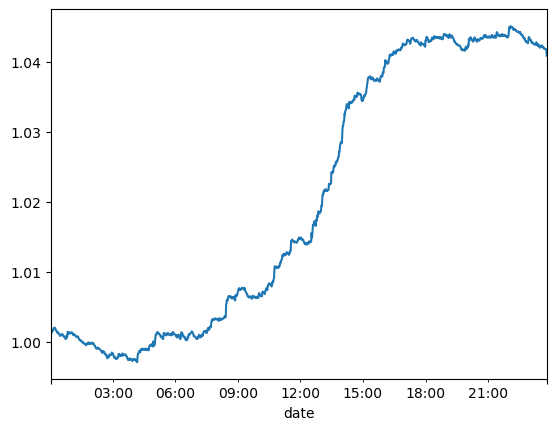

In [74]:
panel_df['date'] = panel_df.index
result = backtest_longshort(panel_df)

#result['sharpe']
result['cumreturn'].plot()
#result['ic'].plot()


In [59]:
panel_df

,buy_volume,sell_volume,buy_count,sell_count,total_volume,total_count,vwap,trade_imbalance,avg_trade_size,buy_avg_size,...,size_p50,size_p75,large_trade_ratio,arrival_rate,toxicity,ret_1,ret_5,ret_10,symbol,date
2025-09-02 00:01:00,1289.2,6242.8,30,20,7532.0,50,0.813224,-0.657674,150.640000,42.973333,...,27.10,42.800,0.040000,0.833333,0.000975,0.001721,0.001045,-0.001230,1000000MOG,2025-09-02 00:01:00
2025-09-02 00:02:00,2347.9,4963.6,16,27,7311.5,43,0.814005,-0.357751,170.034884,146.743750,...,27.10,48.350,0.069767,0.716667,0.001041,-0.001412,-0.001780,-0.001719,1000000MOG,2025-09-02 00:02:00
2025-09-02 00:03:00,3644.5,1836.3,31,8,5480.8,39,0.814452,0.329915,140.533333,117.564516,...,20.30,116.700,0.153846,0.650000,0.000979,0.002274,-0.002274,-0.001537,1000000MOG,2025-09-02 00:03:00
2025-09-02 00:04:00,892.3,10096.1,18,22,10988.4,40,0.815186,-0.837592,274.710000,49.572222,...,28.05,82.825,0.100000,0.666667,0.001514,0.000123,-0.001472,-0.003741,1000000MOG,2025-09-02 00:04:00
2025-09-02 00:05:00,2715.5,3853.2,14,24,6568.7,38,0.815092,-0.173200,172.860526,193.964286,...,41.90,127.625,0.131579,0.633333,0.001028,-0.001656,-0.003004,-0.003372,1000000MOG,2025-09-02 00:05:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-02 23:45:00,9963.2,8892.2,4,4,18855.4,8,0.156446,0.056801,2356.925000,2490.800000,...,490.50,2884.400,0.250000,0.133333,0.001000,0.000639,0.000000,0.000639,BAT,2025-09-02 23:45:00
2025-09-02 23:46:00,727.1,299.3,3,2,1026.4,5,0.156571,0.416797,205.280000,242.366667,...,146.30,201.300,0.200000,0.083333,0.000089,0.000000,-0.000639,0.000639,BAT,2025-09-02 23:46:00
2025-09-02 23:47:00,0.0,39.1,0,1,39.1,1,0.156500,-1.000000,39.100000,0.000000,...,39.10,39.100,0.000000,0.016667,0.000017,0.000000,0.000639,0.000000,BAT,2025-09-02 23:47:00
2025-09-02 23:48:00,0.0,0.0,0,0,0.0,0,0.000000,0.000000,0.000000,0.000000,...,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000639,0.000639,BAT,2025-09-02 23:48:00


In [18]:
# 截面IC示例：计算多个symbol的截面IC（带标准化）

# 获取某日可用的symbols
test_date = '2025-09-01'
available_symbols = get_available_symbols_for_date(test_date)
print(f"{test_date} 可用的symbols数量: {len(available_symbols)}")
print(f"前10个symbols: {available_symbols[:5]}")

factor_cols = factors_col

# 选择一部分symbol进行测试（可以选择更多，但会更慢）
test_symbols = available_symbols[:10]  # 取前10个symbol测试
test_dates_cs = ['2025-09-02']  # 截面IC可以测试多天

print(f"\n计算截面IC...")
print(f"测试symbols: {test_symbols}")
print(f"测试日期: {test_dates_cs}")

# 方法1：使用标准化的截面IC（推荐）
print("\n=== 带标准化的截面IC示例 ===")
panel_df = []

for i in test_symbols:
    if i.endswith('6'):
        continue
    f = get_basic_factors(i, test_dates_cs[0])
    f['symbol'] = i
    panel_df.append(f)

panel_df = pd.concat(panel_df)
if not panel_df.empty:
    print(f"面板数据形状: {panel_df.shape}")
    print(f"包含的symbols: {panel_df['symbol'].unique()}")
    print(factor_cols)
    
    # 计算带标准化的截面IC（推荐用法）
    ic_cs = compute_cross_sectional_ic_with_norm(
        panel_df,                    # 面板数据
        factor_cols,                 # 因子列表
        return_col='ret_1',      # 收益率列名
        method='spearman',           # 相关系数方法：'spearman'（推荐）或'pearson'
        min_symbols=3,               # 每个时间点最少需要的symbol数量
        normalize=True,              # 是否进行截面标准化（强烈推荐True）
        norm_method='zscore',        # 标准化方法：'zscore'（推荐）、'mad'（稳健）、'rank'（无量纲）、'demean'（仅去均值）
        norm_clip=3.0                # 标准化后的截断倍数（防止极端值）
    )
    
    print(ic_cs)
    if not ic_cs.empty:
        print(f"\n截面IC样本（前10行）:")
        print(ic_cs[factor_cols].head(10).round(4))
        
        # 统计分析
        print("\n截面IC统计汇总:")
        summary_cs = ic_summary_statistics(ic_cs, factor_cols)
        print(summary_cs.round(4))
    else:
        print("未能计算截面IC")
else:
    print("未能准备面板数据")

# 方法2：多日截面IC（如果要测试多天）
# print("\n=== 多日截面IC示例（带标准化）===")
# test_dates_multi = ['2025-09-01', '2025-09-02']  # 多个测试日期
# 
# # 循环处理每一天，分别计算截面IC
# ic_results_list = []
# for test_date in test_dates_multi:
#     panel_df_day = prepare_panel_data(test_symbols, test_date, window_s=60)
#     if not panel_df_day.empty:
#         ic_day = compute_cross_sectional_ic_with_norm(
#             panel_df_day,                # 当天的面板数据
#             factor_cols,                 # 因子列表
#             return_col='fwd_ret_1',      # 收益率列名
#             method='spearman',           # 相关系数方法：'spearman'（推荐）或'pearson'
#             min_symbols=3,               # 每个时间点最少需要的symbol数量
#             normalize=True,              # 是否进行截面标准化（强烈推荐True）
#             norm_method='zscore',        # 标准化方法：'zscore'（推荐）、'mad'（稳健）、'rank'（无量纲）、'demean'（仅去均值）
#             norm_clip=3.0                # 标准化后的截断倍数（防止极端值）
#         )
#         ic_results_list.append(ic_day)
# 
# # 合并所有日期的IC结果
# if ic_results_list:
#     ic_cs_multiday = pd.concat(ic_results_list, axis=0)
#     print(f"\n多日截面IC统计（共{len(test_dates_multi)}天）:")
#     summary_cs_multi = ic_summary_statistics(ic_cs_multiday, factor_cols)
#     print(summary_cs_multi.round(4))


2025-09-01 可用的symbols数量: 50
前10个symbols: ['1000000MOG', '1000CAT', '1000RATS', 'ACX', 'AKT']

计算截面IC...
测试symbols: ['1000000MOG', '1000CAT', '1000RATS', 'ACX', 'AKT', 'ALGO', 'ALT', 'ARK', 'AXS', 'BAT']
测试日期: ['2025-09-02']

=== 带标准化的截面IC示例 ===
订单簿索引唯一: True
成交索引唯一: True
订单簿索引唯一: True
成交索引唯一: True
订单簿索引唯一: True
成交索引唯一: True
订单簿索引唯一: True
成交索引唯一: True
订单簿索引唯一: True
成交索引唯一: True
订单簿索引唯一: True
成交索引唯一: True
订单簿索引唯一: True
成交索引唯一: True
订单簿索引唯一: True
成交索引唯一: True
订单簿索引唯一: True
成交索引唯一: True
订单簿索引唯一: True
成交索引唯一: True
面板数据形状: (14288, 44)
包含的symbols: ['1000000MOG' '1000CAT' '1000RATS' 'ACX' 'AKT' 'ALGO' 'ALT' 'ARK' 'AXS'
 'BAT']
['buy_volume', 'sell_volume', 'buy_count', 'sell_count', 'total_volume', 'total_count', 'vwap', 'trade_imbalance', 'avg_trade_size', 'buy_avg_size', 'sell_avg_size', 'total_bid_vol', 'total_ask_vol', 'lob_imb', 'wmid', 'mid', 'spread', 'spread_bps', 'ask_avg_price_5', 'bid_avg_price_5', 'tier1_imb', 'tier2_imb', 'tier3_imb', 'tier4_imb', 'buy_pressure', 'sell_pressure', 

In [26]:
summary_cs

,IC_mean,IC_std,IC_IR,IC_positive_rate,IC_abs_mean,IC_min,IC_max,IC_median,n_samples
factor,,,,,,,,,
buy_volume,0.115043,0.346425,0.332086,0.638209,0.301180,-0.866667,0.915152,0.127273,1429
sell_volume,-0.093402,0.352699,-0.264822,0.389083,0.301292,-0.890909,0.890909,-0.104302,1429
buy_count,0.139272,0.353387,0.394107,0.651505,0.312504,-0.873950,0.963433,0.151515,1429
sell_count,-0.138109,0.334408,-0.412997,0.332400,0.298451,-0.951515,0.824651,-0.153853,1429
total_volume,0.015820,0.357418,0.044263,0.505948,0.294190,-0.890909,0.915152,0.006135,1429
total_count,0.014434,0.355654,0.040585,0.509447,0.290776,-0.862921,0.927273,0.012158,1429
vwap,-0.018904,0.327205,-0.057775,0.468160,0.267335,-0.927273,0.944211,-0.030677,1429
trade_imbalance,0.378559,0.296409,1.277152,0.884535,0.421770,-0.684848,0.939394,0.413376,1429
avg_trade_size,0.014024,0.338085,0.041481,0.520644,0.278253,-0.854545,0.915152,0.018237,1429


### 6.3 可视化示例（可选）


绘制时序IC图表...


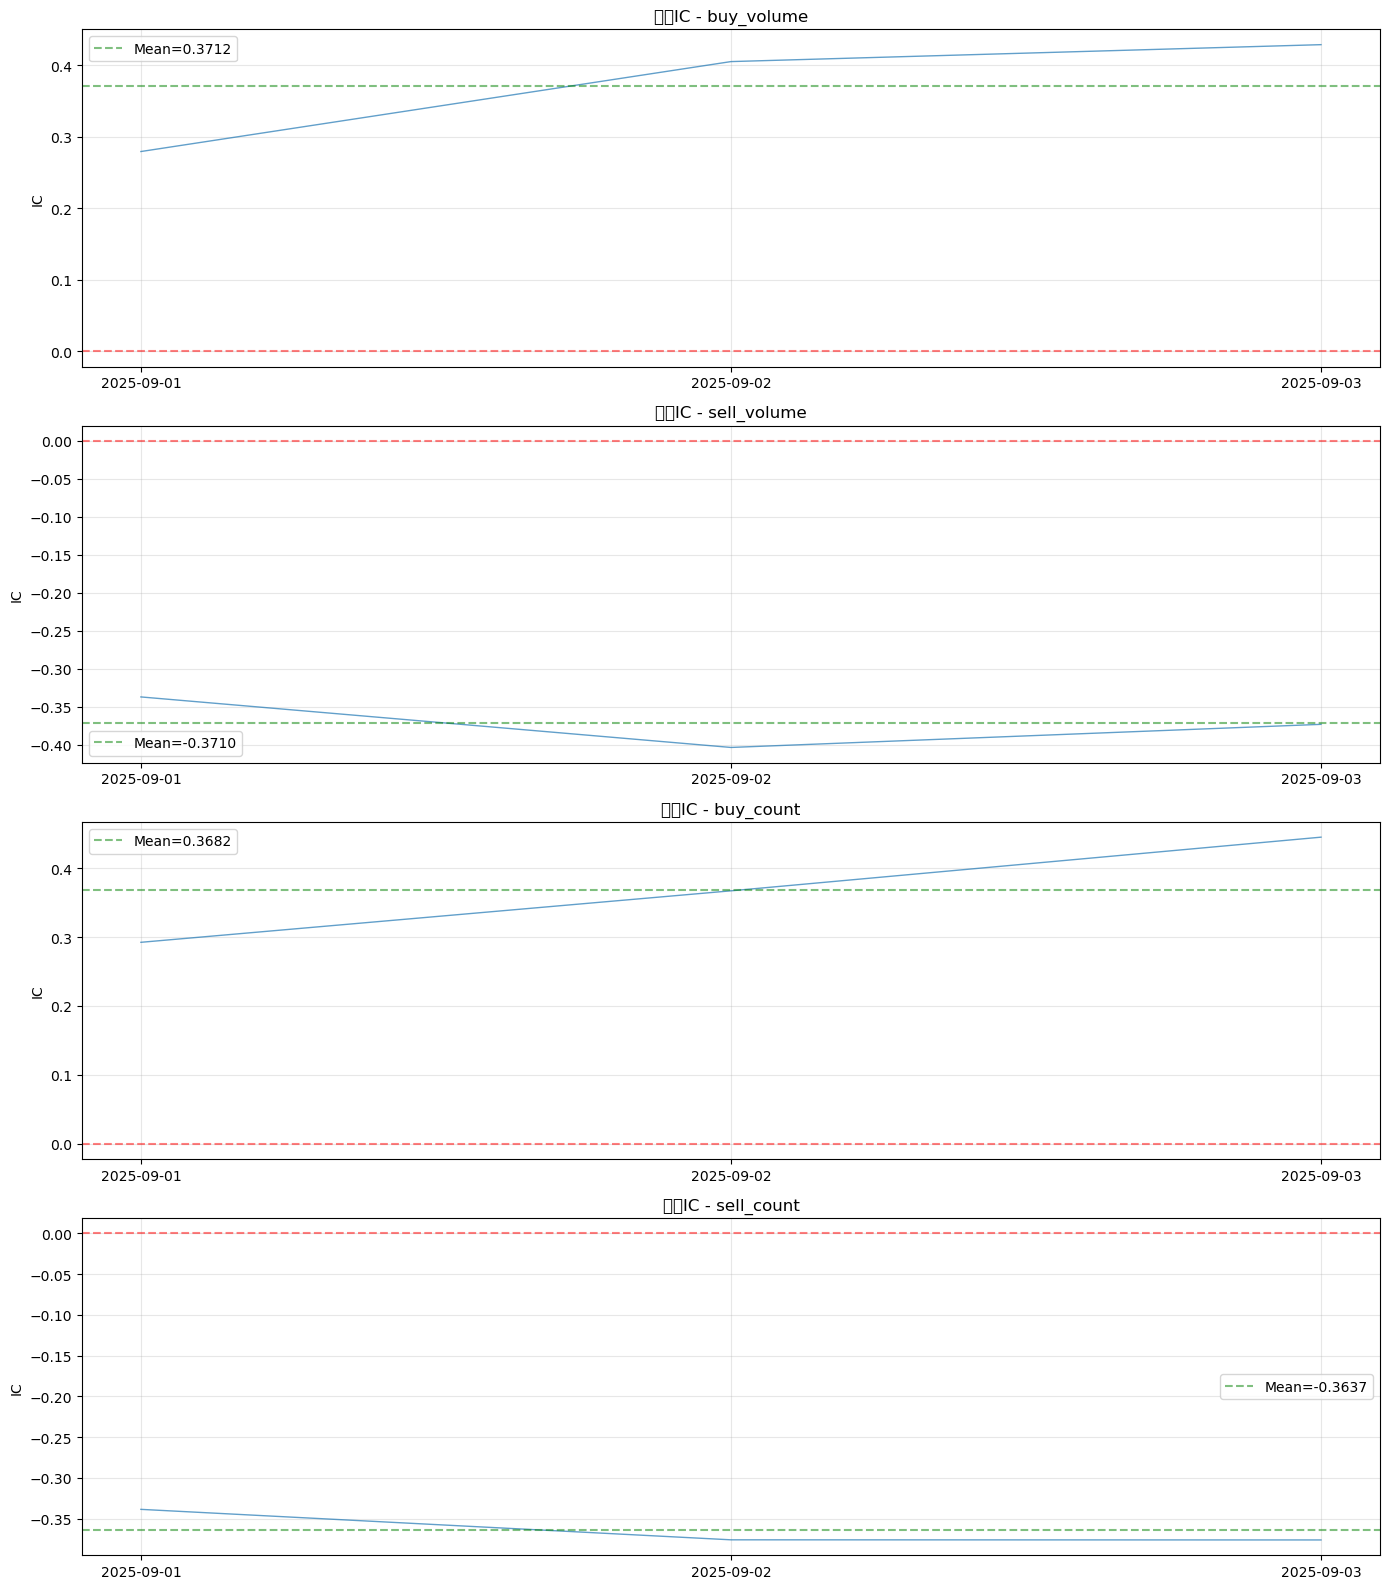

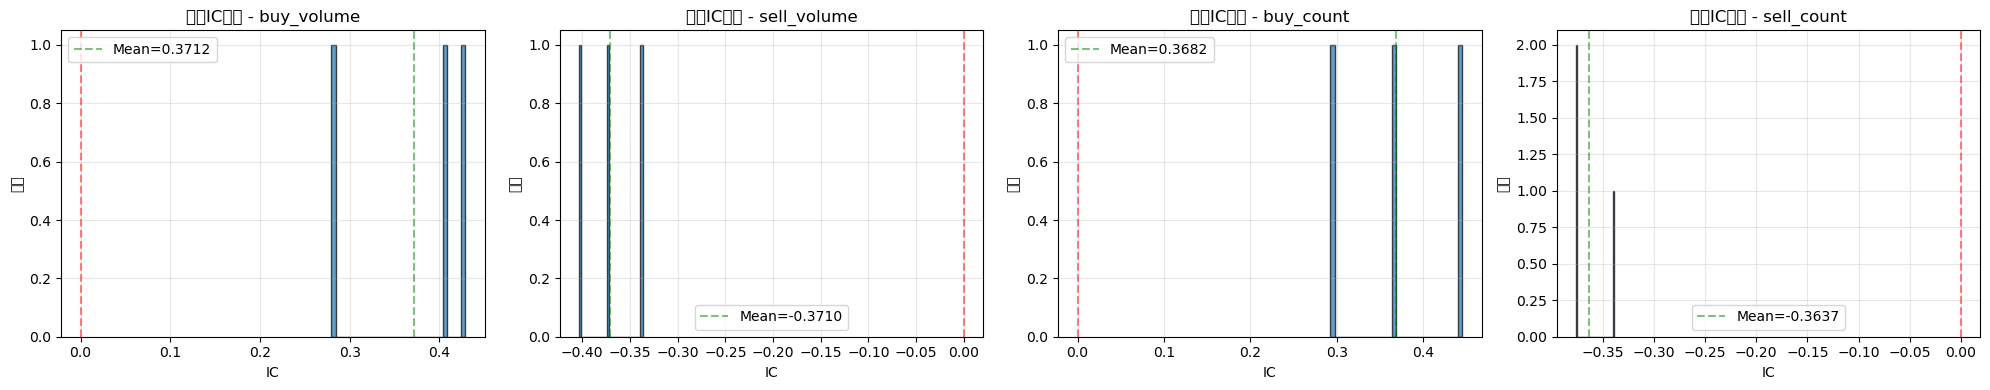

如需绘图，请取消注释上面的绘图代码
绘制截面IC图表...


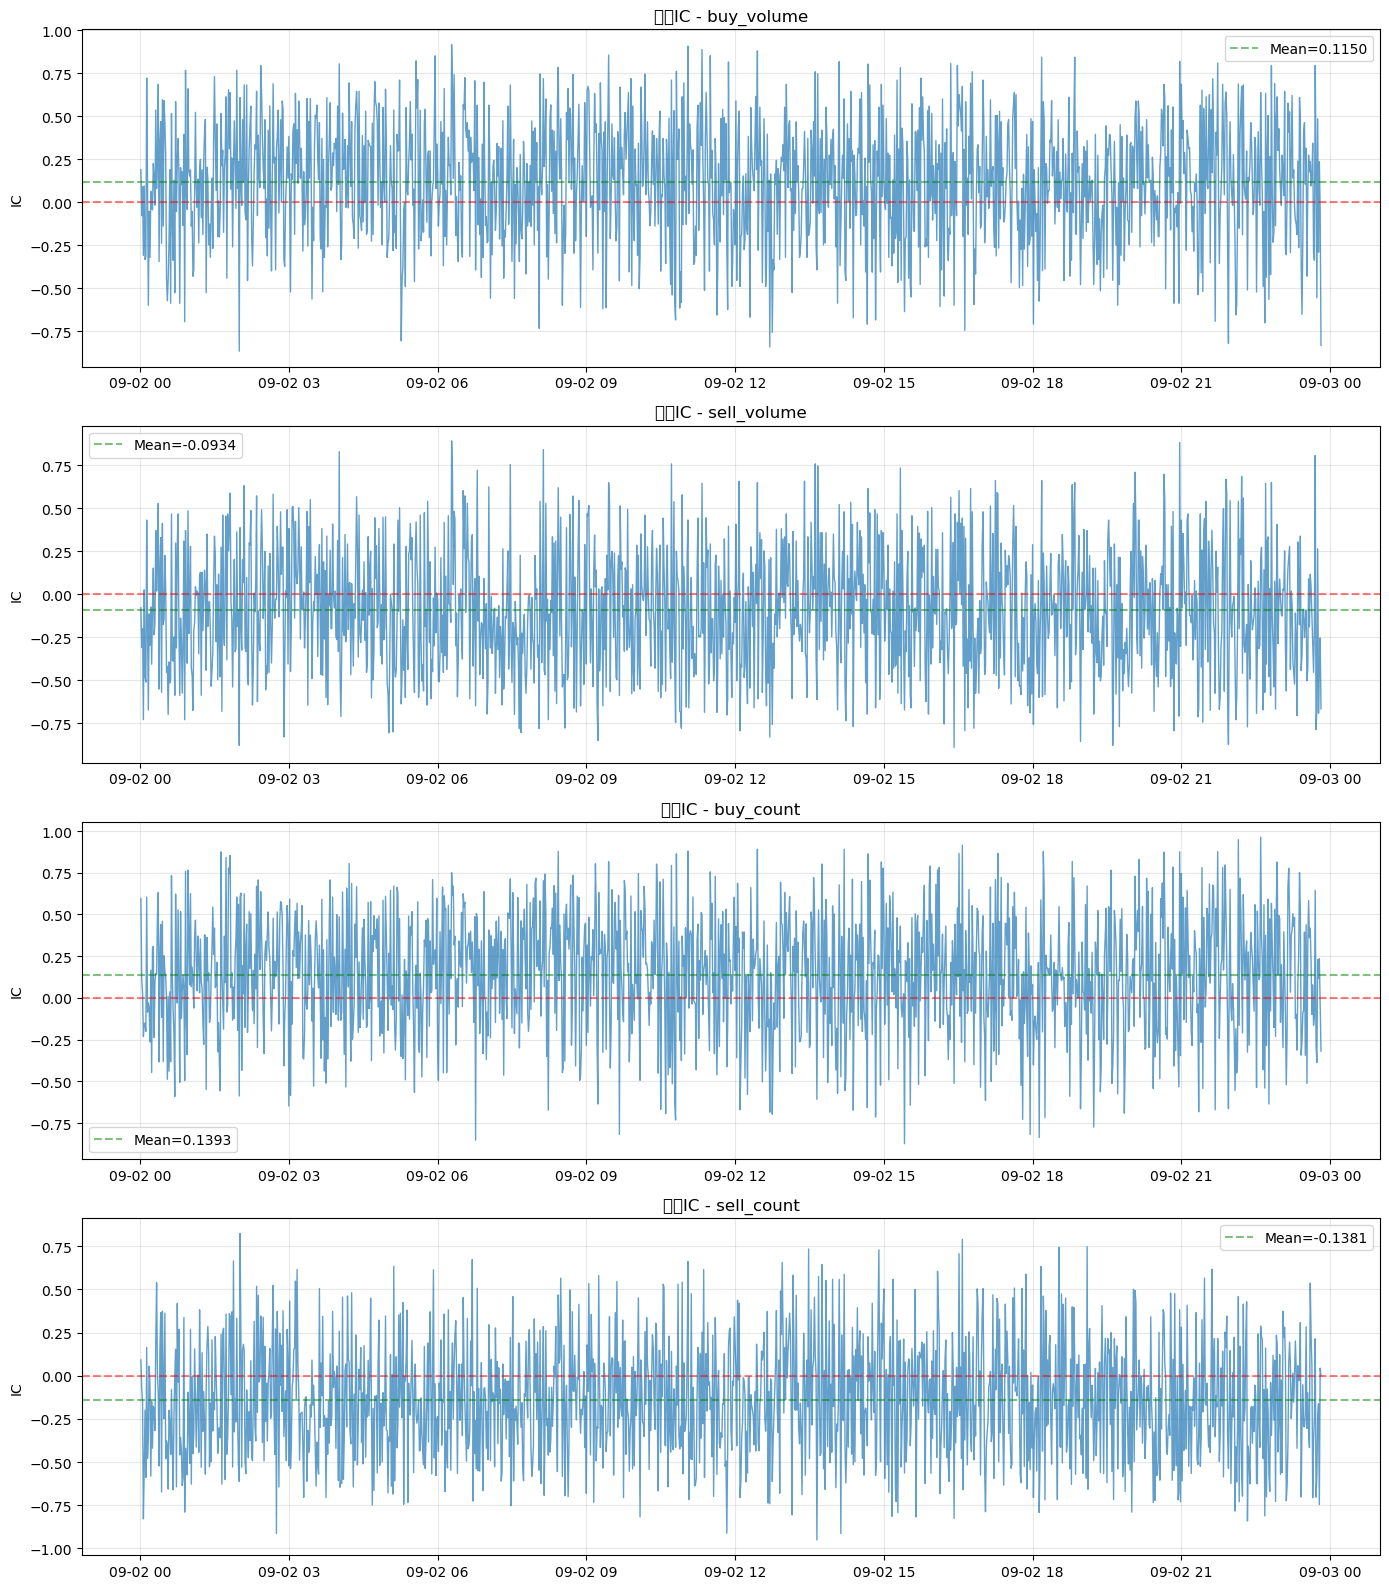

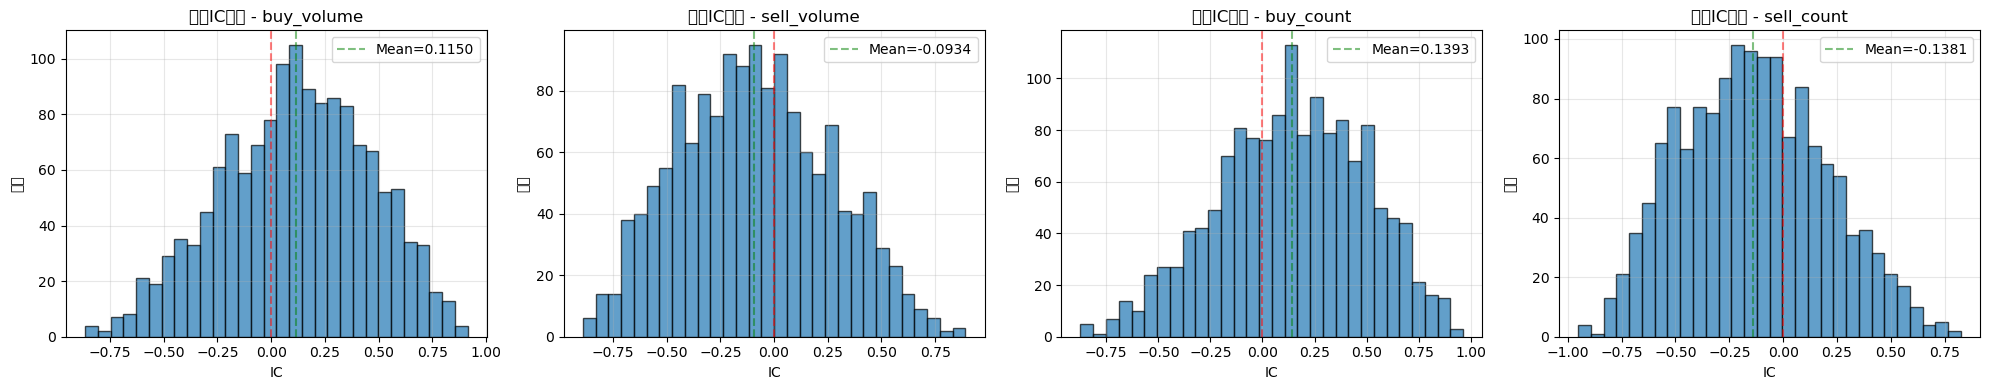

如需绘图，请取消注释上面的绘图代码


In [25]:
# 可视化示例：绘制IC时间序列和分布图

# 如果有多日的时序IC数据
if 'ic_multiday' in locals() and not ic_multiday.empty:
    print("绘制时序IC图表...")
    
    # 选择几个主要因子绘图
    plot_factors = ['buy_volume', 'sell_volume', 'buy_count', 'sell_count']
    
    # IC时间序列图
    plot_ic_timeseries(ic_multiday, plot_factors, title="时序IC")
    
    # IC分布图
    plot_ic_distribution(ic_multiday, plot_factors, title="时序IC分布")
    
    print("如需绘图，请取消注释上面的绘图代码")

# 如果有截面IC数据
if 'ic_cs' in locals() and not ic_cs.empty:
    print("绘制截面IC图表...")
    
    # IC时间序列图
    plot_ic_timeseries(ic_cs, plot_factors, title="截面IC")
    
    # IC分布图
    plot_ic_distribution(ic_cs, plot_factors, title="截面IC分布")
    
    print("如需绘图，请取消注释上面的绘图代码")


## 7. 说明与总结

### 7.2 IC指标解读

- **IC_mean**: IC均值，越大越好（通常>0.03算不错）
- **IC_std**: IC标准差，衡量稳定性
- **IC_IR**: 信息比率 = IC_mean / IC_std，综合衡量预测能力和稳定性
- **IC_positive_rate**: IC为正的比例，>0.5表示因子方向正确的概率大于50%
- **IC_abs_mean**: IC绝对值均值，衡量因子的整体预测强度

### 7.3 参数调整建议

3. **method**: 相关系数方法
   - spearman: 秩相关，对异常值鲁棒，推荐使用
   - pearson: 线性相关，对异常值敏感

### 7.5 使用流程总结

```python
# 1. 计算单个symbol的时序IC
ic_ts = compute_timeseries_ic_multiday(
    symbol='1000CAT',
    dates=['2025-09-01', '2025-09-02'],
    factor_cols=['CR_ask', 'NetOFI'],
    window_s=1.0
)

# 2. 计算多个symbol的截面IC
ic_cs = compute_cross_sectional_ic_multiday(
    symbols=['1000CAT', 'ACX', 'ARK'],
    dates=['2025-09-01'],
    factor_cols=['CR_ask', 'NetOFI'],
    window_s=1.0
)

# 3. 统计分析
summary = ic_summary_statistics(ic_ts, ['CR_ask', 'NetOFI'])

# 4. 可视化（可选）
plot_ic_timeseries(ic_ts, ['CR_ask', 'NetOFI'])
```


## 8. 高级用法：批量计算与并行处理（可选）


In [ ]:
def batch_compute_timeseries_ic(symbols: List[str],
                                 dates: List[str],
                                 factor_cols: List[str],
                                 return_col: str = 'fwd_ret_1',
                                 window_s: float = 1.0,
                                 method: str = 'spearman',
                                 base_path: str = '/Volumes/hft/binance2/202509') -> Dict[str, pd.DataFrame]:
    """
    批量计算多个symbol的时序IC
    
    参数:
        symbols: symbol列表
        dates: 日期列表
        factor_cols: 因子列名列表
        return_col: 收益率列名
        window_s: 时间窗口
        method: 相关系数方法
        base_path: 数据根目录
    
    返回:
        字典 {symbol: IC DataFrame}
    """
    results = {}
    
    for symbol in symbols:
        print(f"处理 {symbol}...")
        try:
            ic_df = compute_timeseries_ic_multiday(
                symbol=symbol,
                dates=dates,
                factor_cols=factor_cols,
                return_col=return_col,
                window_s=window_s,
                method=method,
                base_path=base_path
            )
            if not ic_df.empty:
                results[symbol] = ic_df
        except Exception as e:
            print(f"  {symbol} 出错: {e}")
    
    return results

def aggregate_timeseries_ic_results(results: Dict[str, pd.DataFrame],
                                     factor_cols: List[str]) -> pd.DataFrame:
    """
    汇总多个symbol的时序IC结果
    
    参数:
        results: 字典 {symbol: IC DataFrame}
        factor_cols: 因子列名列表
    
    返回:
        汇总统计DataFrame
    """
    summary_list = []
    
    for symbol, ic_df in results.items():
        summary = ic_summary_statistics(ic_df, factor_cols)
        summary['symbol'] = symbol
        summary_list.append(summary.reset_index())
    
    if not summary_list:
        return pd.DataFrame()
    
    agg_df = pd.concat(summary_list, ignore_index=True)
    return agg_df

# 使用示例（注释掉，需要时取消注释）
# print("\n=== 批量计算时序IC示例 ===")
# test_symbols_batch = ['1000CAT', 'ACX', 'ARK']
# test_dates_batch = ['2025-09-01', '2025-09-02']
# 
# batch_results = batch_compute_timeseries_ic(
#     symbols=test_symbols_batch,
#     dates=test_dates_batch,
#     factor_cols=['CR_ask', 'NetOFI'],
#     window_s=1.0
# )
# 
# if batch_results:
#     print(f"\n成功计算 {len(batch_results)} 个symbol的IC")
#     
#     # 汇总结果
#     agg_summary = aggregate_timeseries_ic_results(batch_results, ['CR_ask', 'NetOFI'])
#     print("\n各symbol的IC汇总:")
#     print(agg_summary[['symbol', 'factor', 'IC_mean', 'IC_IR', 'IC_positive_rate']].round(4))

print("批量计算函数定义完成")


In [ ]:
# 更新后的截面IC示例（使用时间戳对齐）
print("="*80)
print("截面IC计算示例（修复后）")
print("="*80)

# 获取可用symbols
test_date = '2025-09-01'
available_symbols = get_available_symbols_for_date(test_date)
print(f"\n{test_date} 可用symbols: {len(available_symbols)}个")

# 选择一些symbols测试
test_symbols = available_symbols[:5]  # 前5个
print(f"测试symbols: {test_symbols}")

# 准备面板数据（启用时间戳对齐）
print(f"\n准备面板数据（window_s=60）...")
panel_df = prepare_panel_data(
    test_symbols, 
    test_date, 
    window_s=60.0,
    horizons=[1],
    align_timestamps=True  # 关键！
)

if not panel_df.empty:
    print(f"✓ 面板数据shape: {panel_df.shape}")
    print(f"✓ Symbols: {panel_df['symbol'].unique()}")
    
    # 检查时间戳对齐情况
    time_counts = panel_df.index.value_counts()
    print(f"\n时间戳统计:")
    print(f"  - 总时间点: {len(time_counts)}")
    print(f"  - 有 {len(test_symbols)} 个symbol的时间点: {(time_counts == len(test_symbols)).sum()}")
    print(f"  - 有 >= 3 个symbol的时间点: {(time_counts >= 3).sum()}")
    
    # 计算截面IC
    print(f"\n计算截面IC...")
    factor_cols = ['CR_ask', 'CR_bid', 'CAR_ask', 'CAR_bid', 'hazard_ask', 'hazard_bid', 'NetOFI']
    ic_cs = compute_cross_sectional_ic(
        panel_df,
        factor_cols=factor_cols,
        return_col='fwd_ret_1',
        method='spearman',
        min_symbols=3  # 至少需要3个symbol
    )
    
    if not ic_cs.empty:
        print(f"✓ 成功计算截面IC！")
        print(f"  IC时间序列长度: {len(ic_cs)}")
        print(f"\n前10个时间点的IC值:")
        print(ic_cs[factor_cols].head(10).round(4))
        
        # 统计汇总
        print(f"\n截面IC统计汇总:")
        summary = ic_summary_statistics(ic_cs, factor_cols)
        print(summary[['IC_mean', 'IC_std', 'IC_IR', 'IC_positive_rate']].round(4))
        
        print(f"\n✓ 截面IC计算成功！")
    else:
        print(f"✗ 截面IC仍为空")
else:
    print(f"✗ 面板数据为空")


## 9. 高级因子分析（参考Alphalens，适配高频）

本节参考Alphalens的分析框架，添加以下高频因子分析方法：

### 9.1 因子分层收益分析 (Quantile Analysis)
- 将因子值分层（如五分位），观察各层的平均收益
- 多空组合收益（top - bottom quantile）
- 分层收益的时间序列

### 9.2 IC衰减分析 (IC Decay)
- 计算不同预测周期的IC（1bar, 5bar, 10bar等）
- 观察因子预测能力的持续时间
- 高频因子的半衰期估计

### 9.3 因子周转率分析 (Turnover)
- 因子值的自相关性
- 分层持仓的周转率
- 交易成本估算

### 9.4 因子显著性检验
- t检验和p值
- IC的置信区间
- 多重检验校正

### 9.5 高频特有分析
- 日内模式分析（分时段IC）
- 微观结构噪音诊断
- 因子在不同波动率环境下的表现


In [126]:
### 9.1 因子分层收益分析

def quantile_analysis(df: pd.DataFrame, 
                      factor_col: str,
                      return_col: str = 'fwd_ret_1',
                      n_quantiles: int = 5,
                      zero_aware: bool = False) -> pd.DataFrame:
    """
    因子分层收益分析
    
    参数:
        df: 包含因子和收益的DataFrame
        factor_col: 因子列名
        return_col: 收益率列名
        n_quantiles: 分层数量
        zero_aware: 是否将0值单独分组（对于稀疏因子）
    
    返回:
        各分位数的统计信息DataFrame
    """
    df = df.copy()
    
    # 去除NaN
    valid_mask = df[[factor_col, return_col]].notna().all(axis=1)
    df_valid = df[valid_mask].copy()
    
    if len(df_valid) < n_quantiles * 2:
        return pd.DataFrame()
    
    # 分层
    if zero_aware:
        # 将0单独分组，非0值再分层
        zero_mask = df_valid[factor_col] == 0
        df_valid['quantile'] = np.nan
        df_valid.loc[zero_mask, 'quantile'] = 0
        
        # 非0值分层
        non_zero = df_valid[~zero_mask]
        if len(non_zero) > 0:
            df_valid.loc[~zero_mask, 'quantile'] = pd.qcut(
                non_zero[factor_col], 
                q=n_quantiles, 
                labels=False, 
                duplicates='drop'
            ) + 1  # 从1开始编号（0留给零值组）
    else:
        df_valid['quantile'] = pd.qcut(
            df_valid[factor_col], 
            q=n_quantiles, 
            labels=False, 
            duplicates='drop'
        )
    
    # 统计各分位数
    stats = []
    for q in sorted(df_valid['quantile'].dropna().unique()):
        q_mask = df_valid['quantile'] == q
        q_data = df_valid[q_mask]
        
        stat = {
            'quantile': int(q),
            'count': len(q_data),
            'mean_return': q_data[return_col].mean(),
            'std_return': q_data[return_col].std(),
            'sharpe': q_data[return_col].mean() / q_data[return_col].std() if q_data[return_col].std() > 0 else np.nan,
            'mean_factor': q_data[factor_col].mean(),
            'min_factor': q_data[factor_col].min(),
            'max_factor': q_data[factor_col].max()
        }
        stats.append(stat)
    
    result = pd.DataFrame(stats)
    
    # 添加多空组合
    if len(result) >= 2:
        top_return = result.loc[result['quantile'].idxmax(), 'mean_return']
        bottom_return = result.loc[result['quantile'].idxmin(), 'mean_return']
        long_short = {
            'quantile': 'Long-Short',
            'count': np.nan,
            'mean_return': top_return - bottom_return,
            'std_return': np.nan,
            'sharpe': np.nan,
            'mean_factor': np.nan,
            'min_factor': np.nan,
            'max_factor': np.nan
        }
        result = pd.concat([result, pd.DataFrame([long_short])], ignore_index=True)
    
    return result


def quantile_returns_timeseries(df: pd.DataFrame,
                                  factor_col: str,
                                  return_col: str = 'fwd_ret_1',
                                  n_quantiles: int = 5,
                                  resample_freq: str = None) -> pd.DataFrame:
    """
    计算分层收益的时间序列
    
    参数:
        df: 包含因子和收益的DataFrame（需要DatetimeIndex）
        factor_col: 因子列名
        return_col: 收益率列名
        n_quantiles: 分层数量
        resample_freq: 重采样频率（如'5min', '1H'），None表示不重采样
    
    返回:
        各分位数收益的时间序列DataFrame
    """
    df = df.copy()
    valid_mask = df[[factor_col, return_col]].notna().all(axis=1)
    df_valid = df[valid_mask].copy()
    
    if len(df_valid) < n_quantiles * 2:
        return pd.DataFrame()
    
    # 分层
    df_valid['quantile'] = pd.qcut(
        df_valid[factor_col], 
        q=n_quantiles, 
        labels=False, 
        duplicates='drop'
    )
    
    # 计算各分位数的时间序列收益
    quantile_returns = {}
    for q in sorted(df_valid['quantile'].dropna().unique()):
        q_mask = df_valid['quantile'] == q
        quantile_returns[f'Q{int(q)+1}'] = df_valid.loc[q_mask, return_col]
    
    result = pd.DataFrame(quantile_returns)
    
    # 重采样（如果指定）
    if resample_freq is not None:
        result = result.resample(resample_freq).mean()
    
    # 添加多空组合
    if len(result.columns) >= 2:
        result['Long-Short'] = result[result.columns[-1]] - result[result.columns[0]]
    
    return result


def plot_quantile_returns(quantile_stats: pd.DataFrame, 
                          factor_name: str,
                          return_col: str = 'fwd_ret_1'):
    """
    绘制分层收益图
    
    参数:
        quantile_stats: quantile_analysis的返回结果
        factor_name: 因子名称
        return_col: 收益率列名
    """
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 去除Long-Short行
    stats = quantile_stats[quantile_stats['quantile'] != 'Long-Short'].copy()
    stats['quantile'] = stats['quantile'].astype(int)
    stats = stats.sort_values('quantile')
    
    # 左图：各分位数的平均收益
    ax = axes[0]
    bars = ax.bar(stats['quantile'], stats['mean_return'], 
                   color=['red' if x < 0 else 'green' for x in stats['mean_return']],
                   alpha=0.7, edgecolor='black')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_xlabel('Quantile (1=Lowest Factor Value, 5=Highest)', fontsize=11)
    ax.set_ylabel(f'Mean {return_col}', fontsize=11)
    ax.set_title(f'{factor_name} - Returns by Quantile', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 添加数值标签
    for bar, val in zip(bars, stats['mean_return']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.6f}',
                ha='center', va='bottom' if height > 0 else 'top', fontsize=9)
    
    # 右图：各分位数的因子值范围
    ax = axes[1]
    x_pos = np.arange(len(stats))
    ax.barh(x_pos, stats['max_factor'] - stats['min_factor'], 
            left=stats['min_factor'], alpha=0.6, edgecolor='black')
    ax.scatter(stats['mean_factor'], x_pos, color='red', s=50, zorder=3, label='Mean')
    ax.set_yticks(x_pos)
    ax.set_yticklabels([f'Q{int(q)}' for q in stats['quantile']])
    ax.set_xlabel(f'{factor_name} Value', fontsize=11)
    ax.set_ylabel('Quantile', fontsize=11)
    ax.set_title(f'{factor_name} - Value Distribution by Quantile', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    # 额外打印Long-Short信息
    ls_row = quantile_stats[quantile_stats['quantile'] == 'Long-Short']
    if not ls_row.empty:
        ls_return = ls_row.iloc[0]['mean_return']
        print(f"\n{'='*60}")
        print(f"Long-Short Portfolio (Q5 - Q1): {ls_return:.8f}")
        print(f"{'='*60}")


def quantile_backtest(df: pd.DataFrame,
                      factor_col: str,
                      return_col: str = 'fwd_ret_1',
                      date_col: str = 'date',
                      n_quantiles: int = 5,
                      zero_aware: bool = False):
    """
    因子分层收益分析 + 实际回测（按期分层计算收益）

    返回:
        stats_df: 各分位统计表（你的原始功能）
        period_returns: 每期各 quantile 收益
        ls_series: 多空组合收益序列
        cum_curve: 多空累计收益曲线
    """

    df = df.copy()
    
    # 去除 NaN
    df = df[[date_col, factor_col, return_col]].dropna()

    # 按日期排序
    df = df.sort_values(date_col)

    # 存储逐期收益
    period_list = []

    # 逐期截面分层
    for dt, df_slice in df.groupby(date_col):

        if len(df_slice) < n_quantiles * 2:
            continue

        tmp = df_slice.copy()

        # ---- 分层逻辑 ----
        if zero_aware:
            zero_mask = tmp[factor_col] == 0
            tmp['quantile'] = np.nan
            tmp.loc[zero_mask, 'quantile'] = 0

            non_zero = tmp[~zero_mask]
            if len(non_zero) > 0:
                tmp.loc[~zero_mask, 'quantile'] = pd.qcut(
                    non_zero[factor_col],
                    q=n_quantiles,
                    labels=False,
                    duplicates='drop'
                ) + 1
        else:
            tmp['quantile'] = pd.qcut(
                tmp[factor_col],
                q=n_quantiles,
                labels=False,
                duplicates='drop'
            )

        # ---- 统计每期的各分位收益 ----
        q_ret = tmp.groupby('quantile')[return_col].mean()

        for q, r in q_ret.items():
            period_list.append({
                'date': dt,
                'quantile': int(q),
                'return': r
            })

    period_returns = pd.DataFrame(period_list)

    # 无数据直接返回
    if period_returns.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.Series(), pd.Series()

    # ---- 多空组合：最高减最低 ----
    max_q = period_returns['quantile'].max()
    min_q = period_returns['quantile'].min()

    ls_series = (
        period_returns[period_returns['quantile'] == max_q]
        .set_index('date')['return']
        -
        period_returns[period_returns['quantile'] == min_q]
        .set_index('date')['return']
    )

    # 累计收益曲线（可作为回测结果）
    cum_curve = (1 + ls_series).cumprod()

    # ---- 原始统计结果 ----
    stats_df = period_returns.groupby('quantile')['return'].agg(
        count='count',
        mean_return='mean',
        std_return='std'
    ).reset_index()

    stats_df['sharpe'] = stats_df['mean_return'] / stats_df['std_return']

    # 添加 long-short 行
    ls_row = {
        'quantile': 'Long-Short',
        'count': np.nan,
        'mean_return': ls_series.mean(),
        'std_return': ls_series.std(),
        'sharpe': ls_series.mean() / ls_series.std()
    }
    stats_df = pd.concat([stats_df, pd.DataFrame([ls_row])], ignore_index=True)

    return stats_df, period_returns, ls_series, cum_curve

def quantile_ts_backtest(df: pd.DataFrame,
                         factor_col: str,
                         return_col: str = 'ret_1',
                         n_quantiles: int = 5,
                         fee_rate: float = 0.0005):
    """
    单品种时间序列因子回测（分位数 + 多空 + 手续费）

    参数:
        df: 包含因子与未来收益的时间序列数据
        factor_col: 因子列
        return_col: 下一期收益
        n_quantiles: 因子在时间维度上的分层数量
        fee_rate: 手续费率（单边），如 0.0005 = 5bps

    返回:
        stats_df: 各分位数统计
        df[['signal','strategy_ret','cost','net_ret']]: 回测明细
        cum_curve: 净值曲线
    """

    df = df.copy().dropna(subset=[factor_col, return_col])

    # -------- 时间序列分 quantile --------
    df['quantile'] = pd.qcut(
        df[factor_col],
        q=n_quantiles,
        labels=False,
        duplicates='drop'
    )

    # 分位数收益统计
    stats = df.groupby('quantile')[return_col].agg(
        count='count',
        mean_return='mean',
        std_return='std'
    )
    stats['sharpe'] = stats['mean_return'] / stats['std_return']
    stats_df = stats.reset_index()

    # -------- 生成 signal（高做多，低做空）--------
    top_q = df['quantile'].max()
    low_q = df['quantile'].min()

    df['signal'] = 0
    df.loc[df['quantile'] == top_q, 'signal'] = 1   # 做多
    df.loc[df['quantile'] == low_q, 'signal'] = -1  # 做空

    # -------- 策略收益（未扣费）--------
    df['strategy_ret'] = df['signal'] * df[return_col]

    # -------- 手续费（基于换手率）--------
    df['signal_shift'] = df['signal'].shift(1).fillna(0)

    # 换手 = 仓位变化
    df['turnover'] = (df['signal'] - df['signal_shift']).abs()

    # 手续费 = 换手 × 手续费率
    df['cost'] = df['turnover'] * fee_rate

    # -------- 扣除手续费后的净收益 --------
    df['net_ret'] = df['strategy_ret'] - df['cost']

    # -------- 净值曲线 --------
    cum_curve = (1 + df['net_ret']).cumprod()

    return stats_df, df[['signal', 'strategy_ret', 'cost', 'net_ret']], cum_curve




print("因子分层收益分析函数定义完成")


因子分层收益分析函数定义完成


In [114]:
factors_col

['buy_volume',
 'sell_volume',
 'buy_count',
 'sell_count',
 'total_volume',
 'total_count',
 'vwap',
 'trade_imbalance',
 'avg_trade_size',
 'buy_avg_size',
 'sell_avg_size',
 'total_bid_vol',
 'total_ask_vol',
 'lob_imb',
 'wmid',
 'mid',
 'spread',
 'spread_bps',
 'ask_avg_price_5',
 'bid_avg_price_5',
 'tier1_imb',
 'tier2_imb',
 'tier3_imb',
 'tier4_imb',
 'buy_pressure',
 'sell_pressure',
 'net_pressure',
 'buy_intensity',
 'sell_intensity',
 'intensity_ratio',
 'dominant_side',
 'size_mean',
 'size_std',
 'size_max',
 'size_p25',
 'size_p50',
 'size_p75',
 'large_trade_ratio',
 'arrival_rate',
 'toxicity']

In [119]:
quantile_analysis(factors,'trade_imbalance','ret_1')

,quantile,count,mean_return,std_return,sharpe,mean_factor,min_factor,max_factor
0,0,286.0,-0.001419,0.001595,-0.889665,-0.567325,-1.000000,-0.347655
1,1,286.0,-0.001003,0.002071,-0.484531,-0.224725,-0.346766,-0.109034
2,2,285.0,-0.000150,0.002495,-0.060080,-0.001940,-0.108658,0.104738
3,3,286.0,0.000959,0.001813,0.528977,0.225632,0.106715,0.346670
4,4,286.0,0.001479,0.001544,0.958112,0.570936,0.347071,1.000000
5,Long-Short,NaN,0.002898,NaN,NaN,NaN,NaN,NaN


In [122]:
factors

,buy_volume,sell_volume,buy_count,sell_count,total_volume,total_count,vwap,trade_imbalance,avg_trade_size,buy_avg_size,...,size_max,size_p25,size_p50,size_p75,large_trade_ratio,arrival_rate,toxicity,ret_1,ret_5,ret_10
2025-09-01 00:01:00,15605.7,16518.6,12,19,32124.3,31,0.263165,-0.028418,1036.267742,1300.475000,...,11029.3,42.550,164.50,940.550,0.129032,0.516667,0.000852,-0.000759,-0.004555,-0.007592
2025-09-01 00:02:00,13190.5,21913.3,9,14,35103.8,23,0.263020,-0.248486,1526.252174,1465.611111,...,9122.6,131.000,990.60,2154.850,0.130435,0.383333,0.001259,-0.000380,-0.001899,-0.007217
2025-09-01 00:03:00,8111.9,10147.8,5,15,18259.7,20,0.262851,-0.111497,912.985000,1622.380000,...,5760.2,66.175,242.65,904.775,0.150000,0.333333,0.000699,-0.001520,-0.001900,-0.006080
2025-09-01 00:04:00,15798.9,102446.2,13,29,118245.1,42,0.262120,-0.732777,2815.359524,1215.300000,...,28629.5,358.300,1105.05,2458.425,0.142857,0.700000,0.002224,-0.003806,0.001142,-0.004567
2025-09-01 00:05:00,92017.3,73785.0,36,34,165802.3,70,0.261695,0.109964,2368.604286,2556.036111,...,26692.4,267.875,879.35,2536.575,0.157143,1.166667,0.002044,0.001910,0.000000,-0.001910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-01 23:45:00,42062.3,24297.1,11,24,66359.4,35,0.252737,0.267712,1895.982857,3823.845455,...,18289.4,132.000,384.30,2511.700,0.171429,0.583333,0.001510,0.001584,0.000792,-0.001188
2025-09-01 23:46:00,37896.1,59426.4,16,19,97322.5,35,0.253031,-0.221226,2780.642857,2368.506250,...,22371.2,108.750,909.60,2633.150,0.142857,0.583333,0.002206,-0.001186,-0.001186,-0.002373
2025-09-01 23:47:00,17073.5,18426.9,29,13,35500.4,42,0.252353,-0.038124,845.247619,588.741379,...,12845.3,0.400,34.25,472.775,0.095238,0.700000,0.000710,-0.000792,-0.001188,-0.000792
2025-09-01 23:48:00,18604.2,15536.6,29,12,34140.8,41,0.252548,0.089851,832.702439,641.524138,...,9456.0,131.800,265.00,522.000,0.097561,0.683333,0.000629,0.001189,-0.001189,-0.000396


订单簿索引唯一: True
成交索引唯一: True
Index(['T', 'q1', 'q2', 'q3', 'ap1', 'av1', 'ap2', 'av2', 'ap3', 'av3', 'ap4',
       'av4', 'ap5', 'av5', 'ap6', 'av6', 'ap7', 'av7', 'ap8', 'av8', 'ap9',
       'av9', 'ap10', 'av10', 'ap11', 'av11', 'ap12', 'av12', 'ap13', 'av13',
       'ap14', 'av14', 'ap15', 'av15', 'ap16', 'av16', 'ap17', 'av17', 'ap18',
       'av18', 'ap19', 'av19', 'ap20', 'av20', 'bp1', 'bv1', 'bp2', 'bv2',
       'bp3', 'bv3', 'bp4', 'bv4', 'bp5', 'bv5', 'bp6', 'bv6', 'bp7', 'bv7',
       'bp8', 'bv8', 'bp9', 'bv9', 'bp10', 'bv10', 'bp11', 'bv11', 'bp12',
       'bv12', 'bp13', 'bv13', 'bp14', 'bv14', 'bp15', 'bv15', 'bp16', 'bv16',
       'bp17', 'bv17', 'bp18', 'bv18', 'bp19', 'bv19', 'bp20', 'bv20'],
      dtype='object')
订单簿索引唯一: True
成交索引唯一: True
Index(['T', 'q1', 'q2', 'q3', 'ap1', 'av1', 'ap2', 'av2', 'ap3', 'av3', 'ap4',
       'av4', 'ap5', 'av5', 'ap6', 'av6', 'ap7', 'av7', 'ap8', 'av8', 'ap9',
       'av9', 'ap10', 'av10', 'ap11', 'av11', 'ap12', 'av12', 'ap13', 'av13',

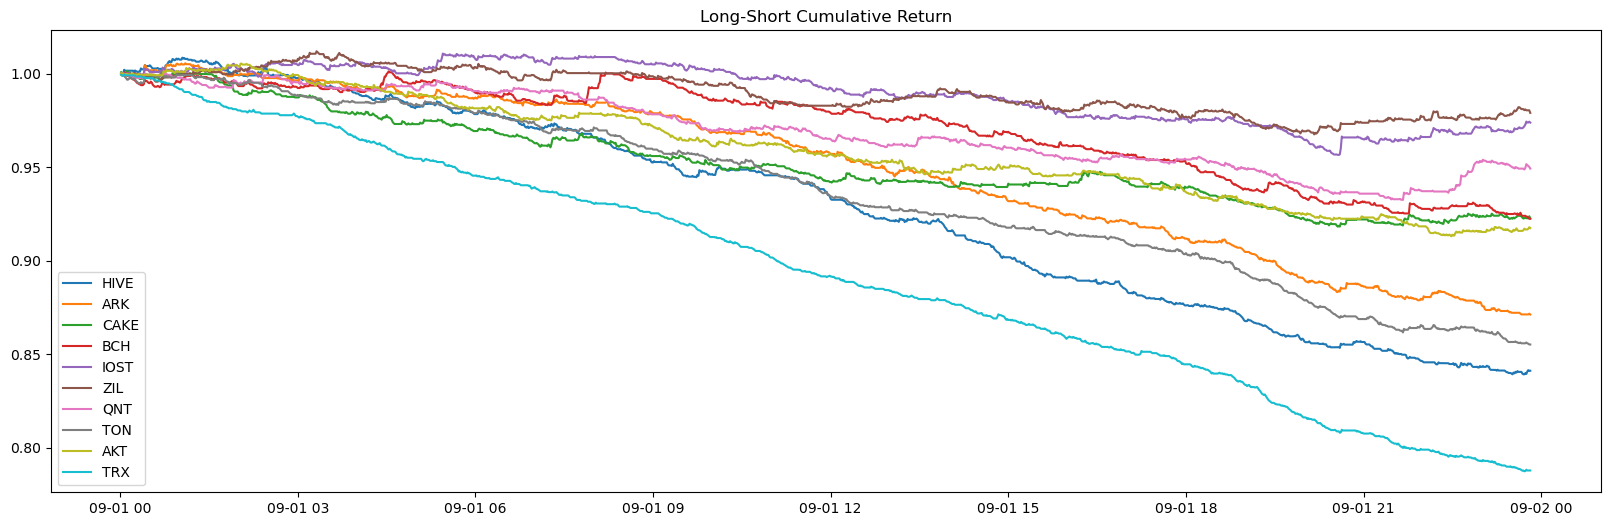

In [135]:
plt.figure(figsize=[20,6])
li = ['HIVE', 'ARK', 'CAKE', 'BCH', 'IOST', 'ZIL', 'QNT', 'TON', 'AKT','TRX']
ret = []
for i in li:
    factors = get_basic_factors(i, '2025-09-01')

    stats_df, df, cum_curve=quantile_ts_backtest(factors,'trade_imbalance','ret_1')
    ret.append(cum_curve)
    plt.plot(cum_curve,label=i)
plt.title("Long-Short Cumulative Return")
plt.legend()
plt.show()

订单簿索引唯一: True
成交索引唯一: True
Index(['T', 'q1', 'q2', 'q3', 'ap1', 'av1', 'ap2', 'av2', 'ap3', 'av3', 'ap4',
       'av4', 'ap5', 'av5', 'ap6', 'av6', 'ap7', 'av7', 'ap8', 'av8', 'ap9',
       'av9', 'ap10', 'av10', 'ap11', 'av11', 'ap12', 'av12', 'ap13', 'av13',
       'ap14', 'av14', 'ap15', 'av15', 'ap16', 'av16', 'ap17', 'av17', 'ap18',
       'av18', 'ap19', 'av19', 'ap20', 'av20', 'bp1', 'bv1', 'bp2', 'bv2',
       'bp3', 'bv3', 'bp4', 'bv4', 'bp5', 'bv5', 'bp6', 'bv6', 'bp7', 'bv7',
       'bp8', 'bv8', 'bp9', 'bv9', 'bp10', 'bv10', 'bp11', 'bv11', 'bp12',
       'bv12', 'bp13', 'bv13', 'bp14', 'bv14', 'bp15', 'bv15', 'bp16', 'bv16',
       'bp17', 'bv17', 'bp18', 'bv18', 'bp19', 'bv19', 'bp20', 'bv20'],
      dtype='object')
订单簿索引唯一: True
成交索引唯一: True
Index(['T', 'q1', 'q2', 'q3', 'ap1', 'av1', 'ap2', 'av2', 'ap3', 'av3', 'ap4',
       'av4', 'ap5', 'av5', 'ap6', 'av6', 'ap7', 'av7', 'ap8', 'av8', 'ap9',
       'av9', 'ap10', 'av10', 'ap11', 'av11', 'ap12', 'av12', 'ap13', 'av13',

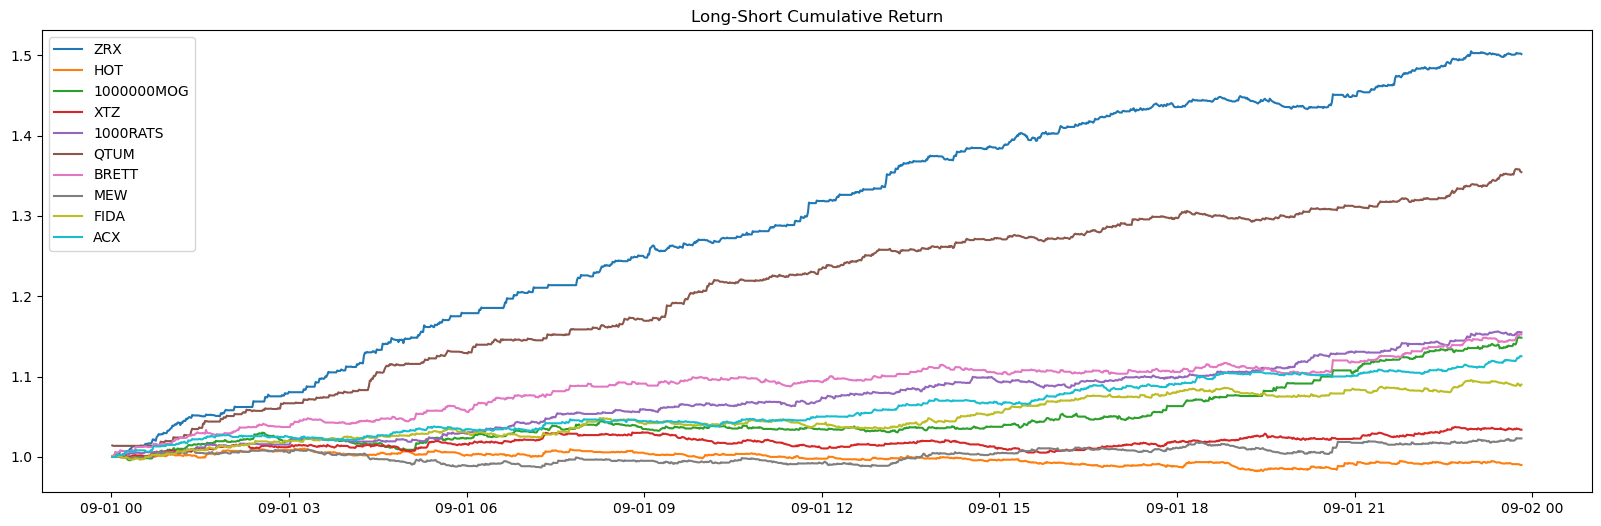

In [131]:
import matplotlib.pyplot as plt
plt.figure(figsize=[20,6])
li = ['ZRX', 'HOT', '1000000MOG', 'XTZ', '1000RATS', 'QTUM', 'BRETT', 'MEW','FIDA', 'ACX']
ret = []
for i in li:
    factors = get_basic_factors(i, '2025-09-01')

    stats_df, df, cum_curve=quantile_ts_backtest(factors,'trade_imbalance','ret_1')
    ret.append(cum_curve)
    plt.plot(cum_curve,label=i)
plt.title("Long-Short Cumulative Return")
plt.legend()
plt.show()

In [36]:
### 9.2 IC衰减分析（高频因子半衰期）

def compute_ic_decay(df: pd.DataFrame,
                     factor_col: str,
                     max_horizon: int = 20,
                     method: str = 'spearman') -> pd.DataFrame:
    """
    计算IC衰减：因子对不同预测周期的IC
    
    参数:
        df: 包含因子的DataFrame（需要DatetimeIndex）
        factor_col: 因子列名
        max_horizon: 最大预测周期
        method: 'spearman' 或 'pearson'
    
    返回:
        IC衰减DataFrame，index为horizon
    """
    from scipy.stats import spearmanr, pearsonr
    
    df = df.copy()
    
    # 确保有mid_price
    if 'mid_price' not in df.columns:
        print("警告：无mid_price列，无法计算IC衰减")
        return pd.DataFrame()
    
    ic_decay = []
    
    for horizon in range(1, max_horizon + 1):
        # 计算该周期的收益率
        fwd_ret = np.log(df['mid_price'].shift(-horizon) / df['mid_price'])
        
        # 去除NaN
        valid_mask = df[[factor_col]].notna().all(axis=1) & fwd_ret.notna()
        
        if valid_mask.sum() < 10:
            ic_decay.append({
                'horizon': horizon,
                'IC': np.nan,
                'n_samples': 0
            })
            continue
        
        factor_vals = df.loc[valid_mask, factor_col].values
        return_vals = fwd_ret[valid_mask].values
        
        # 计算IC
        if method == 'spearman':
            ic, p_value = spearmanr(factor_vals, return_vals)
        else:
            ic, p_value = pearsonr(factor_vals, return_vals)
        
        ic_decay.append({
            'horizon': horizon,
            'IC': ic,
            'IC_abs': abs(ic),
            'p_value': p_value,
            'n_samples': valid_mask.sum()
        })
    
    result = pd.DataFrame(ic_decay).set_index('horizon')
    return result


def estimate_factor_half_life(ic_decay_df: pd.DataFrame, 
                                threshold: float = 0.5) -> dict:
    """
    估计因子半衰期：IC衰减到初始值一半所需的周期数
    
    参数:
        ic_decay_df: compute_ic_decay的返回结果
        threshold: 半衰期阈值（0.5表示衰减到一半）
    
    返回:
        包含半衰期信息的字典
    """
    if ic_decay_df.empty or 'IC_abs' not in ic_decay_df.columns:
        return {'half_life': np.nan, 'initial_IC': np.nan}
    
    ic_abs = ic_decay_df['IC_abs'].dropna()
    
    if len(ic_abs) == 0:
        return {'half_life': np.nan, 'initial_IC': np.nan}
    
    initial_ic = ic_abs.iloc[0]
    target_ic = initial_ic * threshold
    
    # 找到第一个低于target_ic的位置
    below_target = ic_abs[ic_abs < target_ic]
    
    if len(below_target) == 0:
        half_life = np.nan
    else:
        half_life = below_target.index[0]
    
    return {
        'half_life': half_life,
        'initial_IC': initial_ic,
        'target_IC': target_ic,
        'threshold': threshold
    }


def plot_ic_decay(ic_decay_df: pd.DataFrame, 
                  factor_name: str,
                  show_half_life: bool = True):
    """
    绘制IC衰减图
    
    参数:
        ic_decay_df: compute_ic_decay的返回结果
        factor_name: 因子名称
        show_half_life: 是否标注半衰期
    """
    import matplotlib.pyplot as plt
    
    if ic_decay_df.empty:
        print("IC衰减数据为空")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 左图：IC vs Horizon
    ax = axes[0]
    horizons = ic_decay_df.index
    ic_vals = ic_decay_df['IC'].values
    
    ax.plot(horizons, ic_vals, marker='o', linewidth=2, markersize=5, label='IC')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_xlabel('Forecast Horizon (bars)', fontsize=11)
    ax.set_ylabel('IC', fontsize=11)
    ax.set_title(f'{factor_name} - IC Decay', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # 标注半衰期
    if show_half_life:
        half_life_info = estimate_factor_half_life(ic_decay_df)
        if not np.isnan(half_life_info['half_life']):
            ax.axvline(x=half_life_info['half_life'], color='red', 
                      linestyle='--', linewidth=1.5, 
                      label=f"Half-life ≈ {half_life_info['half_life']} bars")
            ax.legend()
    
    # 右图：|IC| vs Horizon（对数坐标，看衰减率）
    ax = axes[1]
    ic_abs_vals = ic_decay_df['IC_abs'].values
    
    ax.plot(horizons, ic_abs_vals, marker='s', linewidth=2, markersize=5, 
            color='orange', label='|IC|')
    ax.set_xlabel('Forecast Horizon (bars)', fontsize=11)
    ax.set_ylabel('|IC|', fontsize=11)
    ax.set_title(f'{factor_name} - Absolute IC Decay', fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend()
    
    # 标注半衰期
    if show_half_life:
        if not np.isnan(half_life_info['half_life']):
            ax.axhline(y=half_life_info['target_IC'], color='red', 
                      linestyle='--', linewidth=1, alpha=0.7,
                      label=f"50% threshold")
            ax.axvline(x=half_life_info['half_life'], color='red', 
                      linestyle='--', linewidth=1.5)
            ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 打印半衰期信息
    if show_half_life:
        print(f"\n{'='*60}")
        print(f"Factor: {factor_name}")
        print(f"Initial IC: {half_life_info['initial_IC']:.6f}")
        if not np.isnan(half_life_info['half_life']):
            print(f"Half-life: {half_life_info['half_life']} bars")
            print(f"(IC decays to {half_life_info['target_IC']:.6f})")
        else:
            print(f"Half-life: Not reached within {ic_decay_df.index.max()} bars")
        print(f"{'='*60}")


print("IC衰减分析函数定义完成")


IC衰减分析函数定义完成


In [37]:
### 9.3 因子周转率与自相关分析

def compute_factor_autocorrelation(df: pd.DataFrame,
                                     factor_col: str,
                                     max_lag: int = 20) -> pd.DataFrame:
    """
    计算因子值的自相关性
    
    参数:
        df: 包含因子的DataFrame（需要DatetimeIndex）
        factor_col: 因子列名
        max_lag: 最大滞后期
    
    返回:
        自相关系数DataFrame
    """
    from scipy.stats import spearmanr
    
    df = df.copy()
    
    if factor_col not in df.columns:
        return pd.DataFrame()
    
    autocorr = []
    factor_vals = df[factor_col].dropna()
    
    for lag in range(1, max_lag + 1):
        if len(factor_vals) <= lag:
            break
        
        # 计算滞后相关
        corr, p_val = spearmanr(
            factor_vals.iloc[:-lag].values,
            factor_vals.iloc[lag:].values
        )
        
        autocorr.append({
            'lag': lag,
            'autocorr': corr,
            'p_value': p_val
        })
    
    result = pd.DataFrame(autocorr).set_index('lag')
    return result


def compute_quantile_turnover(df: pd.DataFrame,
                                factor_col: str,
                                n_quantiles: int = 5,
                                lag: int = 1) -> dict:
    """
    计算分层持仓的周转率
    
    参数:
        df: 包含因子的DataFrame（需要DatetimeIndex）
        factor_col: 因子列名
        n_quantiles: 分层数量
        lag: 时间间隔（bars）
    
    返回:
        包含周转率信息的字典
    """
    df = df.copy()
    
    if factor_col not in df.columns or len(df) <= lag:
        return {}
    
    # 当前分层
    df['quantile_now'] = pd.qcut(
        df[factor_col], 
        q=n_quantiles, 
        labels=False, 
        duplicates='drop'
    )
    
    # lag期后的分层
    df['quantile_lag'] = df['quantile_now'].shift(lag)
    
    # 去除NaN
    valid_mask = df[['quantile_now', 'quantile_lag']].notna().all(axis=1)
    df_valid = df[valid_mask]
    
    if len(df_valid) == 0:
        return {}
    
    # 计算整体周转率（位置变化的比例）
    turnover = (df_valid['quantile_now'] != df_valid['quantile_lag']).mean()
    
    # 计算各分层的周转率
    quantile_turnover = {}
    for q in sorted(df_valid['quantile_now'].unique()):
        # 当前在该分层的样本
        in_q_now = df_valid['quantile_now'] == q
        # 之前也在该分层的样本
        in_q_before = df_valid.loc[in_q_now, 'quantile_lag'] == q
        # 周转率 = 1 - 保留率
        retention = in_q_before.mean() if in_q_now.sum() > 0 else 0
        quantile_turnover[f'Q{int(q)+1}'] = 1 - retention
    
    return {
        'overall_turnover': turnover,
        'quantile_turnover': quantile_turnover,
        'lag': lag,
        'n_samples': len(df_valid)
    }


def plot_factor_autocorr(autocorr_df: pd.DataFrame, 
                          factor_name: str):
    """
    绘制因子自相关图
    
    参数:
        autocorr_df: compute_factor_autocorrelation的返回结果
        factor_name: 因子名称
    """
    import matplotlib.pyplot as plt
    
    if autocorr_df.empty:
        print("自相关数据为空")
        return
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    lags = autocorr_df.index
    autocorr_vals = autocorr_df['autocorr'].values
    
    # 绘制条形图
    colors = ['green' if x > 0 else 'red' for x in autocorr_vals]
    ax.bar(lags, autocorr_vals, color=colors, alpha=0.7, edgecolor='black')
    
    # 添加显著性阈值线（±1.96/sqrt(n)，95%置信区间）
    n = len(autocorr_df)
    threshold = 1.96 / np.sqrt(n)
    ax.axhline(y=threshold, color='blue', linestyle='--', linewidth=1, 
              alpha=0.7, label=f'95% CI: ±{threshold:.3f}')
    ax.axhline(y=-threshold, color='blue', linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    
    ax.set_xlabel('Lag (bars)', fontsize=11)
    ax.set_ylabel('Autocorrelation', fontsize=11)
    ax.set_title(f'{factor_name} - Autocorrelation Function', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 打印统计信息
    print(f"\n{'='*60}")
    print(f"Factor: {factor_name}")
    print(f"Lag-1 Autocorrelation: {autocorr_df.loc[1, 'autocorr']:.4f}")
    
    # 计算衰减到0.1所需的lag
    below_01 = autocorr_df[autocorr_df['autocorr'].abs() < 0.1]
    if len(below_01) > 0:
        decay_lag = below_01.index[0]
        print(f"Decorrelation Time (|ρ| < 0.1): {decay_lag} bars")
    else:
        print(f"Decorrelation Time: > {autocorr_df.index.max()} bars")
    print(f"{'='*60}")


print("因子周转率与自相关分析函数定义完成")


因子周转率与自相关分析函数定义完成


In [38]:
### 9.4 IC显著性检验与置信区间

def ic_significance_test(ic_series: pd.Series, 
                          alpha: float = 0.05) -> dict:
    """
    IC显著性检验
    
    参数:
        ic_series: IC时间序列
        alpha: 显著性水平
    
    返回:
        包含检验结果的字典
    """
    from scipy import stats
    
    ic_vals = ic_series.dropna()
    
    if len(ic_vals) == 0:
        return {}
    
    n = len(ic_vals)
    mean_ic = ic_vals.mean()
    std_ic = ic_vals.std()
    se_ic = std_ic / np.sqrt(n)
    
    # t检验：H0: IC = 0
    t_stat = mean_ic / se_ic if se_ic > 0 else 0
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-1))
    
    # 置信区间
    t_critical = stats.t.ppf(1 - alpha/2, df=n-1)
    ci_lower = mean_ic - t_critical * se_ic
    ci_upper = mean_ic + t_critical * se_ic
    
    return {
        'n_samples': n,
        'mean_IC': mean_ic,
        'std_IC': std_ic,
        'se_IC': se_ic,
        't_statistic': t_stat,
        'p_value': p_value,
        'is_significant': p_value < alpha,
        'alpha': alpha,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper
    }


def plot_ic_with_confidence(ic_df: pd.DataFrame,
                             factor_cols: List[str],
                             alpha: float = 0.05):
    """
    绘制IC时间序列并标注置信区间
    
    参数:
        ic_df: IC时间序列DataFrame
        factor_cols: 因子列名列表
        alpha: 显著性水平
    """
    import matplotlib.pyplot as plt
    
    n_factors = len(factor_cols)
    fig, axes = plt.subplots(n_factors, 1, figsize=(14, 4*n_factors))
    
    if n_factors == 1:
        axes = [axes]
    
    for ax, factor in zip(axes, factor_cols):
        if factor not in ic_df.columns:
            continue
        
        ic_series = ic_df[factor].dropna()
        
        if len(ic_series) == 0:
            continue
        
        # 计算显著性
        sig_test = ic_significance_test(ic_series, alpha)
        
        # 绘制IC时间序列
        ax.plot(ic_series.index, ic_series.values, 
               linewidth=1, alpha=0.7, label='IC')
        
        # 均值线
        ax.axhline(y=sig_test['mean_IC'], color='green', linestyle='--', 
                  linewidth=1.5, label=f"Mean IC = {sig_test['mean_IC']:.4f}")
        
        # 置信区间
        ax.axhline(y=sig_test['ci_lower'], color='blue', linestyle=':', 
                  linewidth=1, alpha=0.7)
        ax.axhline(y=sig_test['ci_upper'], color='blue', linestyle=':', 
                  linewidth=1, alpha=0.7, label=f"{int((1-alpha)*100)}% CI")
        ax.fill_between(ic_series.index, sig_test['ci_lower'], sig_test['ci_upper'],
                       color='blue', alpha=0.1)
        
        # 零线
        ax.axhline(y=0, color='red', linestyle='-', linewidth=0.8)
        
        # 标题包含显著性信息
        sig_marker = "✓" if sig_test['is_significant'] else "✗"
        title = f"{factor} - IC Time Series\n"
        title += f"Significant: {sig_marker} (p={sig_test['p_value']:.4f}, α={alpha})"
        ax.set_title(title, fontsize=11, fontweight='bold')
        
        ax.set_ylabel('IC', fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def multiple_testing_correction(p_values: dict, 
                                  method: str = 'bonferroni') -> dict:
    """
    多重检验校正
    
    参数:
        p_values: 字典 {因子名: p值}
        method: 校正方法，'bonferroni' 或 'holm'
    
    返回:
        校正后的显著性判断字典
    """
    from scipy.stats import false_discovery_control
    
    n = len(p_values)
    results = {}
    
    if method == 'bonferroni':
        # Bonferroni校正：α_corrected = α / n
        for factor, p_val in p_values.items():
            results[factor] = {
                'p_value': p_val,
                'corrected_alpha': 0.05 / n,
                'is_significant': p_val < 0.05 / n,
                'method': 'Bonferroni'
            }
    
    elif method == 'holm':
        # Holm-Bonferroni校正
        sorted_items = sorted(p_values.items(), key=lambda x: x[1])
        for i, (factor, p_val) in enumerate(sorted_items):
            corrected_alpha = 0.05 / (n - i)
            results[factor] = {
                'p_value': p_val,
                'corrected_alpha': corrected_alpha,
                'is_significant': p_val < corrected_alpha,
                'method': 'Holm-Bonferroni'
            }
    
    return results


print("IC显著性检验函数定义完成")


IC显著性检验函数定义完成


In [39]:
### 9.5 高频特有分析

def intraday_ic_analysis(df: pd.DataFrame,
                          factor_col: str,
                          return_col: str = 'fwd_ret_1',
                          method: str = 'spearman',
                          hour_bins: List[int] = None) -> pd.DataFrame:
    """
    日内IC分析：观察因子在不同时段的表现
    
    参数:
        df: 包含因子和收益的DataFrame（需要DatetimeIndex）
        factor_col: 因子列名
        return_col: 收益率列名
        method: 相关系数方法
        hour_bins: 小时分组（如[0,6,12,18,24]），None表示每小时一组
    
    返回:
        各时段的IC统计DataFrame
    """
    from scipy.stats import spearmanr, pearsonr
    
    df = df.copy()
    
    if not isinstance(df.index, pd.DatetimeIndex):
        print("需要DatetimeIndex")
        return pd.DataFrame()
    
    # 添加小时列
    df['hour'] = df.index.hour
    
    # 分组
    if hour_bins is None:
        # 每小时一组
        groups = df.groupby('hour')
        group_labels = [f"{h:02d}:00-{h:02d}:59" for h in range(24)]
    else:
        # 自定义分组
        df['hour_bin'] = pd.cut(df['hour'], bins=hour_bins, right=False)
        groups = df.groupby('hour_bin')
        group_labels = None
    
    # 计算各组IC
    ic_by_hour = []
    
    for name, group in groups:
        valid_mask = group[[factor_col, return_col]].notna().all(axis=1)
        
        if valid_mask.sum() < 10:
            ic_by_hour.append({
                'time_period': str(name),
                'IC': np.nan,
                'n_samples': valid_mask.sum()
            })
            continue
        
        factor_vals = group.loc[valid_mask, factor_col].values
        return_vals = group.loc[valid_mask, return_col].values
        
        if method == 'spearman':
            ic, p_val = spearmanr(factor_vals, return_vals)
        else:
            ic, p_val = pearsonr(factor_vals, return_vals)
        
        ic_by_hour.append({
            'time_period': str(name),
            'IC': ic,
            'IC_abs': abs(ic),
            'p_value': p_val,
            'n_samples': valid_mask.sum()
        })
    
    result = pd.DataFrame(ic_by_hour)
    return result


def volatility_regime_analysis(df: pd.DataFrame,
                                 factor_col: str,
                                 return_col: str = 'fwd_ret_1',
                                 vol_window: int = 20,
                                 n_regimes: int = 3,
                                 method: str = 'spearman') -> pd.DataFrame:
    """
    波动率环境分析：观察因子在不同波动率环境下的表现
    
    参数:
        df: 包含因子和收益的DataFrame（需要mid_price）
        factor_col: 因子列名
        return_col: 收益率列名
        vol_window: 波动率计算窗口
        n_regimes: 波动率分组数
        method: 相关系数方法
    
    返回:
        各波动率环境的IC统计DataFrame
    """
    from scipy.stats import spearmanr, pearsonr
    
    df = df.copy()
    
    # 计算滚动波动率
    if 'mid_price' in df.columns:
        returns = np.log(df['mid_price'] / df['mid_price'].shift(1))
        df['volatility'] = returns.rolling(window=vol_window).std()
    else:
        print("需要mid_price列计算波动率")
        return pd.DataFrame()
    
    # 波动率分组
    df['vol_regime'] = pd.qcut(
        df['volatility'], 
        q=n_regimes, 
        labels=[f'Low (Q{i+1})' for i in range(n_regimes)],
        duplicates='drop'
    )
    
    # 计算各组IC
    ic_by_vol = []
    
    for regime in df['vol_regime'].dropna().unique():
        regime_data = df[df['vol_regime'] == regime]
        
        valid_mask = regime_data[[factor_col, return_col]].notna().all(axis=1)
        
        if valid_mask.sum() < 10:
            ic_by_vol.append({
                'volatility_regime': regime,
                'IC': np.nan,
                'mean_vol': regime_data['volatility'].mean(),
                'n_samples': valid_mask.sum()
            })
            continue
        
        factor_vals = regime_data.loc[valid_mask, factor_col].values
        return_vals = regime_data.loc[valid_mask, return_col].values
        
        if method == 'spearman':
            ic, p_val = spearmanr(factor_vals, return_vals)
        else:
            ic, p_val = pearsonr(factor_vals, return_vals)
        
        ic_by_vol.append({
            'volatility_regime': regime,
            'IC': ic,
            'IC_abs': abs(ic),
            'p_value': p_val,
            'mean_vol': regime_data['volatility'].mean(),
            'n_samples': valid_mask.sum()
        })
    
    result = pd.DataFrame(ic_by_vol)
    return result


def plot_intraday_ic(intraday_ic_df: pd.DataFrame, 
                      factor_name: str):
    """
    绘制日内IC模式图
    
    参数:
        intraday_ic_df: intraday_ic_analysis的返回结果
        factor_name: 因子名称
    """
    import matplotlib.pyplot as plt
    
    if intraday_ic_df.empty:
        print("日内IC数据为空")
        return
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    x_labels = intraday_ic_df['time_period'].values
    ic_vals = intraday_ic_df['IC'].values
    
    colors = ['green' if x > 0 else 'red' for x in ic_vals]
    bars = ax.bar(range(len(x_labels)), ic_vals, color=colors, alpha=0.7, edgecolor='black')
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_xlabel('Time Period', fontsize=11)
    ax.set_ylabel('IC', fontsize=11)
    ax.set_title(f'{factor_name} - Intraday IC Pattern', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 添加数值标签
    for i, (bar, val) in enumerate(zip(bars, ic_vals)):
        if not np.isnan(val):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.3f}',
                    ha='center', va='bottom' if height > 0 else 'top', fontsize=8)
    
    plt.tight_layout()
    plt.show()


def microstructure_noise_diagnostic(df: pd.DataFrame,
                                      return_col: str = 'fwd_ret_1',
                                      max_lag: int = 5) -> dict:
    """
    微观结构噪音诊断：通过收益率自相关检测噪音
    
    参数:
        df: 包含收益率的DataFrame
        return_col: 收益率列名
        max_lag: 最大滞后期
    
    返回:
        噪音诊断结果字典
    """
    from scipy.stats import spearmanr
    
    if return_col not in df.columns:
        return {}
    
    returns = df[return_col].dropna()
    
    if len(returns) < max_lag + 1:
        return {}
    
    # 计算收益率自相关
    autocorr_list = []
    for lag in range(1, max_lag + 1):
        if len(returns) <= lag:
            break
        corr, _ = spearmanr(returns.iloc[:-lag].values, returns.iloc[lag:].values)
        autocorr_list.append(corr)
    
    # 噪音指标：Lag-1自相关应该接近-0.5（bid-ask bounce）
    lag1_autocorr = autocorr_list[0] if len(autocorr_list) > 0 else np.nan
    
    # 方差比检验（VR统计量）
    # VR = Var(r_t + r_{t-1}) / (2 * Var(r_t))
    # 无噪音时VR=1，有噪音时VR<1
    var_1 = returns.var()
    returns_2 = (returns + returns.shift(1)).dropna()
    var_2 = returns_2.var()
    variance_ratio = var_2 / (2 * var_1) if var_1 > 0 else np.nan
    
    return {
        'lag1_autocorr': lag1_autocorr,
        'variance_ratio': variance_ratio,
        'has_noise': lag1_autocorr < -0.2 or variance_ratio < 0.8,
        'autocorr_profile': autocorr_list
    }


print("高频特有分析函数定义完成")


高频特有分析函数定义完成


In [40]:
### 9.6 综合分析工具与可视化

def comprehensive_factor_report(df: pd.DataFrame,
                                  factor_col: str,
                                  return_col: str = 'fwd_ret_1',
                                  n_quantiles: int = 5,
                                  max_horizon: int = 20,
                                  max_lag: int = 20) -> dict:
    """
    生成因子的综合分析报告
    
    参数:
        df: 包含因子和收益的DataFrame
        factor_col: 因子列名
        return_col: 收益率列名
        n_quantiles: 分层数量
        max_horizon: IC衰减最大周期
        max_lag: 自相关最大滞后期
    
    返回:
        包含所有分析结果的字典
    """
    report = {
        'factor_name': factor_col,
        'n_samples': len(df),
        'date_range': (df.index.min(), df.index.max()) if isinstance(df.index, pd.DatetimeIndex) else (None, None)
    }
    
    # 1. 基础统计
    factor_vals = df[factor_col].dropna()
    report['factor_stats'] = {
        'mean': factor_vals.mean(),
        'std': factor_vals.std(),
        'skew': factor_vals.skew(),
        'kurtosis': factor_vals.kurtosis(),
        'min': factor_vals.min(),
        'max': factor_vals.max(),
        'zeros_pct': (factor_vals == 0).mean()
    }
    
    # 2. IC分析
    ic_dict = compute_timeseries_ic(df, [factor_col], return_col)
    if factor_col in ic_dict:
        report['ic'] = ic_dict[factor_col]
        
        # IC显著性检验
        ic_series = pd.Series([ic_dict[factor_col]])
        sig_test = ic_significance_test(ic_series)
        report['ic_significance'] = sig_test
    
    # 3. 分层收益
    quantile_stats = quantile_analysis(df, factor_col, return_col, n_quantiles)
    report['quantile_analysis'] = quantile_stats
    
    # 4. IC衰减
    ic_decay = compute_ic_decay(df, factor_col, max_horizon)
    report['ic_decay'] = ic_decay
    
    if not ic_decay.empty:
        half_life = estimate_factor_half_life(ic_decay)
        report['half_life'] = half_life
    
    # 5. 因子自相关
    autocorr = compute_factor_autocorrelation(df, factor_col, max_lag)
    report['autocorrelation'] = autocorr
    
    # 6. 周转率
    turnover = compute_quantile_turnover(df, factor_col, n_quantiles)
    report['turnover'] = turnover
    
    # 7. 微观结构噪音
    noise_diag = microstructure_noise_diagnostic(df, return_col)
    report['microstructure_noise'] = noise_diag
    
    return report


def plot_comprehensive_analysis(report: dict, 
                                  show_plots: List[str] = ['quantile', 'ic_decay', 'autocorr']):
    """
    绘制综合分析图表
    
    参数:
        report: comprehensive_factor_report的返回结果
        show_plots: 要显示的图表列表
    """
    import matplotlib.pyplot as plt
    
    factor_name = report['factor_name']
    
    # 图表1：分层收益
    if 'quantile' in show_plots and 'quantile_analysis' in report:
        quantile_stats = report['quantile_analysis']
        if not quantile_stats.empty:
            plot_quantile_returns(quantile_stats, factor_name)
    
    # 图表2：IC衰减
    if 'ic_decay' in show_plots and 'ic_decay' in report:
        ic_decay = report['ic_decay']
        if not ic_decay.empty:
            plot_ic_decay(ic_decay, factor_name)
    
    # 图表3：因子自相关
    if 'autocorr' in show_plots and 'autocorrelation' in report:
        autocorr = report['autocorrelation']
        if not autocorr.empty:
            plot_factor_autocorr(autocorr, factor_name)


def plot_ic_heatmap(ic_multiday_dict: dict,
                     factor_cols: List[str],
                     figsize: tuple = (14, 8)):
    """
    绘制IC热力图：时间 x 因子
    
    参数:
        ic_multiday_dict: 字典 {symbol: ic_df}，或者单个ic_df
        factor_cols: 因子列名列表
        figsize: 图表大小
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 统一处理输入
    if isinstance(ic_multiday_dict, pd.DataFrame):
        ic_df = ic_multiday_dict
    elif isinstance(ic_multiday_dict, dict):
        # 合并多个symbol的IC
        ic_df = pd.concat([df for df in ic_multiday_dict.values()], axis=0)
    else:
        print("输入格式错误")
        return
    
    # 确保有时间索引
    if not isinstance(ic_df.index, pd.DatetimeIndex):
        if 'date' in ic_df.columns:
            ic_df = ic_df.set_index('date')
            ic_df.index = pd.to_datetime(ic_df.index)
        else:
            print("需要DatetimeIndex或date列")
            return
    
    # 选择因子列
    ic_matrix = ic_df[factor_cols].dropna(how='all')
    
    if ic_matrix.empty:
        print("无有效IC数据")
        return
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # 绘制热力图
    sns.heatmap(ic_matrix.T, cmap='RdYlGn', center=0, 
                cbar_kws={'label': 'IC'}, ax=ax,
                linewidths=0.5, linecolor='gray')
    
    ax.set_xlabel('Time', fontsize=11)
    ax.set_ylabel('Factor', fontsize=11)
    ax.set_title('IC Heatmap: Factors vs Time', fontsize=12, fontweight='bold')
    
    # 调整x轴标签
    if len(ic_matrix) > 20:
        # 只显示部分日期标签
        n_labels = 10
        step = len(ic_matrix) // n_labels
        tick_positions = range(0, len(ic_matrix), step)
        tick_labels = [ic_matrix.index[i].strftime('%Y-%m-%d') for i in tick_positions]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()


def rolling_ic_analysis(df: pd.DataFrame,
                         factor_col: str,
                         return_col: str = 'fwd_ret_1',
                         window: int = 100,
                         method: str = 'spearman') -> pd.DataFrame:
    """
    滚动窗口IC分析：观察IC的时间稳定性
    
    参数:
        df: 包含因子和收益的DataFrame
        factor_col: 因子列名
        return_col: 收益率列名
        window: 滚动窗口大小
        method: 相关系数方法
    
    返回:
        滚动IC的时间序列DataFrame
    """
    from scipy.stats import spearmanr, pearsonr
    
    df = df.copy()
    
    valid_mask = df[[factor_col, return_col]].notna().all(axis=1)
    df_valid = df[valid_mask].copy()
    
    if len(df_valid) < window:
        return pd.DataFrame()
    
    rolling_ic = []
    
    for i in range(window, len(df_valid) + 1):
        window_data = df_valid.iloc[i-window:i]
        
        factor_vals = window_data[factor_col].values
        return_vals = window_data[return_col].values
        
        if method == 'spearman':
            ic, p_val = spearmanr(factor_vals, return_vals)
        else:
            ic, p_val = pearsonr(factor_vals, return_vals)
        
        rolling_ic.append({
            'end_time': window_data.index[-1],
            'IC': ic,
            'p_value': p_val
        })
    
    result = pd.DataFrame(rolling_ic).set_index('end_time')
    return result


def plot_rolling_ic(rolling_ic_df: pd.DataFrame,
                     factor_name: str,
                     window: int):
    """
    绘制滚动IC图
    
    参数:
        rolling_ic_df: rolling_ic_analysis的返回结果
        factor_name: 因子名称
        window: 窗口大小
    """
    import matplotlib.pyplot as plt
    
    if rolling_ic_df.empty:
        print("滚动IC数据为空")
        return
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # 上图：滚动IC
    ax = axes[0]
    ax.plot(rolling_ic_df.index, rolling_ic_df['IC'].values, 
           linewidth=1.5, alpha=0.8, label=f'{window}-bar Rolling IC')
    ax.axhline(y=0, color='red', linestyle='-', linewidth=0.8)
    ax.axhline(y=rolling_ic_df['IC'].mean(), color='green', 
              linestyle='--', linewidth=1.5, label=f"Mean = {rolling_ic_df['IC'].mean():.4f}")
    ax.fill_between(rolling_ic_df.index, 0, rolling_ic_df['IC'].values,
                    where=rolling_ic_df['IC'].values > 0, color='green', alpha=0.2)
    ax.fill_between(rolling_ic_df.index, 0, rolling_ic_df['IC'].values,
                    where=rolling_ic_df['IC'].values < 0, color='red', alpha=0.2)
    ax.set_ylabel('IC', fontsize=11)
    ax.set_title(f'{factor_name} - Rolling IC (window={window})', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 下图：IC分布直方图
    ax = axes[1]
    ax.hist(rolling_ic_df['IC'].dropna().values, bins=30, 
           alpha=0.7, edgecolor='black', color='steelblue')
    ax.axvline(x=0, color='red', linestyle='-', linewidth=1.5)
    ax.axvline(x=rolling_ic_df['IC'].mean(), color='green', 
              linestyle='--', linewidth=1.5, label=f"Mean = {rolling_ic_df['IC'].mean():.4f}")
    ax.set_xlabel('IC', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title('IC Distribution', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()


print("综合分析工具与可视化函数定义完成")


综合分析工具与可视化函数定义完成


## 10. 高级分析使用示例

以下演示如何使用新增的高级分析功能


In [81]:
df_factor

,start_time,duration_s,C_A,C_B,E_A,E_B,A_A,A_B,DepthTime_A,DepthTime_B,...,label,lvl_can_A,lvl_can_B,lvl_add_A,lvl_add_B,mid_price,symbol,fwd_ret_1,fwd_ret_5,fwd_ret_10
end_time,,,,,,,,,,,,,,,,,,,,,
2025-09-05 00:01:08.526,2025-09-05 00:00:08.526,60.0,18666.2,138562.2,27.5,23.7,40322.6,154721.0,5.780812e+06,6.635326e+06,...,time_60s,"[3071.1999999999994, 5405.599999999999, 3117.6...","[14243.695135135138, 11908.749110032362, 8916....","[1235.3999999999999, 3182.5999999999985, 3908....","[7607.199999999999, 10089.8, 9814.9, 8962.3, 8...",1.0845,AKT,0.000922,0.001842,0.002762
2025-09-05 00:02:08.526,2025-09-05 00:01:08.526,60.0,45136.1,216230.2,0.0,0.0,40465.0,224111.6,6.653782e+06,8.993810e+06,...,time_60s,"[8357.3, 8429.900000000001, 2568.2999999999984...","[11015.200000000003, 9418.899999999998, 10628....","[6201.799999999999, 1671.1000000000004, 1298.0...","[10486.699999999999, 11240.100000000002, 10791...",1.0855,AKT,0.000921,0.000000,0.001841
2025-09-05 00:03:08.526,2025-09-05 00:02:08.526,60.0,32467.0,178861.0,9.2,10.8,30159.8,179653.7,6.267710e+06,8.216283e+06,...,time_60s,"[7964.599999999999, 5611.999999999999, 908.900...","[7288.400000000001, 9242.7, 8693.3, 9172.40000...","[2812.5000000000005, 4114.5999999999985, 871.3...","[6677.1, 8505.999999999998, 9211.8, 8819.40000...",1.0865,AKT,0.000000,-0.001842,0.000920
2025-09-05 00:04:08.526,2025-09-05 00:03:08.526,60.0,38904.4,42372.0,15.6,79.0,33747.1,48989.9,6.377238e+06,8.430353e+06,...,time_60s,"[6788.6, 2981.1999999999953, 1781.300000000001...","[3626.7833668678745, 3288.7000000000035, 566.6...","[4344.799999999999, 1564.399999999996, 1869.80...","[7141.4, 5984.500000000004, 1059.3999999999996...",1.0865,AKT,0.000000,-0.001842,0.003675
2025-09-05 00:05:08.526,2025-09-05 00:04:08.526,60.0,3833.8,7504.8,11.1,128.7,6085.2,9338.8,6.136337e+06,8.584245e+06,...,time_60s,"[1573.6, 1429.7000000000066, 804.199999999998,...","[2389.100000000001, 2606.500000000002, 57.7999...","[1353.0, 1635.400000000007, 663.9999999999982,...","[2181.8, 2652.9000000000015, 1187.299999999999...",1.0865,AKT,0.000000,-0.001842,0.003675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-05 23:55:08.526,2025-09-05 23:54:08.526,60.0,1488.5,3797.2,0.0,0.0,1400.0,4729.6,6.176391e+06,9.438800e+06,...,time_60s,"[315.20000000000005, 104.5, 48.60000000000037,...","[0.0, 1500.0, 4.600000000000364, 0.0, 629.8000...","[326.70000000000005, 4.5, 48.600000000000364, ...","[104.5, 1500.0, 4.600000000000364, 0.0, 898.90...",1.1135,AKT,0.000000,0.000000,NaN
2025-09-05 23:56:08.526,2025-09-05 23:55:08.526,60.0,2183.7,3695.3,0.0,0.0,1914.7,3589.8,5.946851e+06,9.186772e+06,...,time_60s,"[147.8, 4.5, 453.60000000000036, 468.600000000...","[99.40000000000053, 1800.0, 58.600000000000364...","[695.5999999999999, 104.5, 5.400000000001455, ...","[5.100000000000364, 1800.0, 53.20000000000073,...",1.1135,AKT,0.000000,NaN,NaN
2025-09-05 23:57:08.526,2025-09-05 23:56:08.526,60.0,2127.0,17742.6,4.2,11.8,2352.8,2959.2,5.950188e+06,9.122442e+06,...,time_60s,"[275.0000000000001, 57.69999999999982, 21.6000...","[200.69999999999982, 250.0, 10.00000000000091,...","[234.80000000000018, 603.9000000000005, 16.200...","[4.5, 200.0, 65.40000000000055, 0.0, 629.80000...",1.1135,AKT,0.000000,NaN,NaN


In [82]:
quantile_stats

,quantile,count,mean_return,std_return,sharpe,mean_factor,min_factor,max_factor
0,0,288.0,-0.000054,0.000919,-0.058609,-15059.620833,-73817.8,-6219.8
1,1,288.0,-0.000043,0.000772,-0.055877,-2832.772569,-6185.1,-761.5
2,2,287.0,0.000016,0.000585,0.027075,-13.627526,-761.3,849.9
3,3,288.0,0.000053,0.000796,0.067144,2642.515972,856.0,5762.3
4,4,288.0,0.000119,0.000717,0.166352,15272.187153,5765.6,67797.2
5,Long-Short,NaN,0.000173,NaN,NaN,NaN,NaN,NaN


In [41]:
factors

,buy_volume,sell_volume,buy_count,sell_count,total_volume,total_count,vwap,trade_imbalance,avg_trade_size,buy_avg_size,...,size_max,size_p25,size_p50,size_p75,large_trade_ratio,arrival_rate,toxicity,ret_1,ret_5,ret_10
2025-09-01 00:01:00,48549.8,98924.5,13,7,147474.3,20,0.149791,-0.341583,7373.715000,3734.600000,...,36974.6,359.875,1866.20,14139.400,0.200000,0.333333,0.003843,0.001001,-0.002670,-0.002670
2025-09-01 00:02:00,30488.4,36985.8,5,7,67474.2,12,0.149955,-0.096295,5622.850000,6097.680000,...,26583.6,156.175,720.15,8915.500,0.166667,0.200000,0.002473,-0.000667,-0.000667,-0.004668
2025-09-01 00:03:00,3586.1,19706.9,4,6,23293.0,10,0.149895,-0.692088,2329.300000,896.525000,...,18004.2,82.800,248.45,635.175,0.100000,0.166667,0.000984,0.000000,0.000000,-0.003337
2025-09-01 00:04:00,17835.7,41997.3,17,12,59833.0,29,0.149490,-0.403817,2063.206897,1049.158824,...,10464.9,108.000,650.00,2516.300,0.241379,0.483333,0.000873,-0.004004,-0.000667,-0.003337
2025-09-01 00:05:00,68147.7,70727.5,26,15,138875.2,41,0.149164,-0.018576,3387.200000,2621.065385,...,30000.0,148.100,431.50,3329.500,0.170732,0.683333,0.001414,0.001005,0.002010,-0.000670
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-01 23:45:00,39010.9,6304.1,28,14,45315.0,42,0.151946,0.721765,1078.928571,1393.246429,...,14470.9,39.350,80.35,379.200,0.119048,0.700000,0.000473,0.001977,0.000000,0.000000
2025-09-01 23:46:00,28452.9,32903.6,29,16,61356.5,45,0.152101,-0.072538,1363.477778,981.134483,...,9640.3,39.400,119.00,1331.600,0.155556,0.750000,0.000621,-0.000329,-0.001315,-0.000658
2025-09-01 23:47:00,15236.2,19813.1,28,11,35049.3,39,0.151882,-0.130585,898.700000,544.150000,...,15092.3,37.600,64.90,254.350,0.102564,0.650000,0.000397,-0.000987,-0.002303,0.001645
2025-09-01 23:48:00,937.5,2924.7,21,7,3862.2,28,0.151684,-0.514525,137.935714,44.642857,...,941.4,37.300,39.35,74.900,0.178571,0.466667,0.000059,-0.001317,-0.000659,0.003951


=== 因子分层收益分析示例 ===
Symbol: AKT, Date: 2025-09-05, Factor: trade_imbalance

1. 五分位分层收益分析:
     quantile  count  mean_return  std_return    sharpe  mean_factor  \
0           0  286.0    -0.000851    0.000772 -1.102220    -0.805385   
1           1  286.0    -0.000422    0.000975 -0.432372    -0.340620   
2           2  285.0     0.000021    0.001012  0.020288     0.105718   
3           3  286.0     0.000463    0.000909  0.509071     0.556004   
4           4  286.0     0.000837    0.000789  1.061385     0.921415   
5  Long-Short    NaN     0.001688         NaN       NaN          NaN   

   min_factor  max_factor  
0   -1.000000   -0.576570  
1   -0.576493   -0.097822  
2   -0.096934    0.313691  
3    0.314262    0.771820  
4    0.772520    1.000000  
5         NaN         NaN  


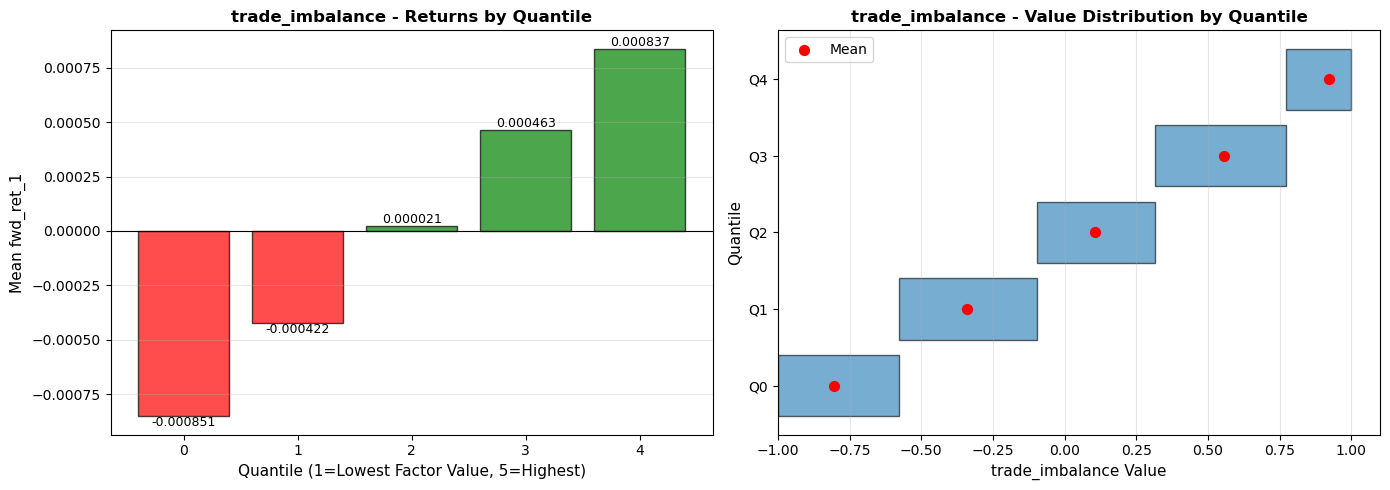


Long-Short Portfolio (Q5 - Q1): 0.00168825

2. 分层收益时间序列（前5行）:
                      Q1        Q2        Q3  Q4  Q5  Long-Short
2025-09-01 00:01:00  NaN  0.001001       NaN NaN NaN         NaN
2025-09-01 00:02:00  NaN       NaN -0.000667 NaN NaN         NaN
2025-09-01 00:03:00  0.0       NaN       NaN NaN NaN         NaN
2025-09-01 00:04:00  NaN -0.004004       NaN NaN NaN         NaN
2025-09-01 00:05:00  NaN       NaN  0.001005 NaN NaN         NaN

多空组合平均收益: nan


In [44]:
### 10.1 示例：因子分层收益分析

# 准备数据
test_symbol = 'AKT'
test_date = '2025-09-05'
test_factor = 'trade_imbalance'

print(f"=== 因子分层收益分析示例 ===")
print(f"Symbol: {test_symbol}, Date: {test_date}, Factor: {test_factor}\n")

# 计算因子数据
'''
df_factor = prepare_factor_return_data(test_symbol, test_date, window_s=60, horizons=[1, 5, 10])
print(df_factor.iloc[0,:])
print(df_factor.columns)
'''
if not factors.empty:
    # 1. 基础分层分析
    print("1. 五分位分层收益分析:")
    quantile_stats = quantile_analysis(factors, test_factor, 'ret_1', n_quantiles=5)
    print(quantile_stats.round(6))
    
    # 2. 可视化
    plot_quantile_returns(quantile_stats, test_factor)
    
    # 3. 分层收益时间序列
    print("\n2. 分层收益时间序列（前5行）:")
    quantile_ts = quantile_returns_timeseries(factors, test_factor, 'ret_1', n_quantiles=5)
    if not quantile_ts.empty:
        print(quantile_ts.head())
        print(f"\n多空组合平均收益: {quantile_ts['Long-Short'].mean():.8f}")
else:
    print("数据加载失败")


In [45]:
### 10.2 示例：IC衰减与因子半衰期

print(f"\n=== IC衰减分析示例 ===")

if not factors.empty:
    # 1. 计算IC衰减
    ic_decay = compute_ic_decay(factors, test_factor, max_horizon=20)
    
    if not ic_decay.empty:
        print("\nIC衰减表（前10期）:")
        print(ic_decay.head(10).round(6))
        
        # 2. 估计半衰期
        half_life_info = estimate_factor_half_life(ic_decay)
        print(f"\n半衰期分析:")
        print(f"  初始IC: {half_life_info['initial_IC']:.6f}")
        if not np.isnan(half_life_info['half_life']):
            print(f"  半衰期: {half_life_info['half_life']} bars")
        else:
            print(f"  半衰期: 未达到（超过{ic_decay.index.max()}期）")
        
        # 3. 可视化
        # plot_ic_decay(ic_decay, test_factor, show_half_life=True)
        
        print("\n说明：")
        print("  - 半衰期短(<5 bars)：适合超短线策略")
        print("  - 半衰期中等(5-20 bars)：适合短线策略")
        print("  - 半衰期长(>20 bars)：因子持续性强")
    else:
        print("IC衰减计算失败")
else:
    print("数据加载失败")



=== IC衰减分析示例 ===
警告：无mid_price列，无法计算IC衰减
IC衰减计算失败


In [46]:
### 10.3 示例：因子自相关与周转率

print(f"\n=== 因子自相关与周转率分析 ===")

if not factors.empty:
    # 1. 因子自相关
    autocorr = compute_factor_autocorrelation(factors, test_factor, max_lag=20)
    
    if not autocorr.empty:
        print("\n因子自相关（前5个滞后期）:")
        print(autocorr.head().round(4))
        
        print(f"\nLag-1自相关: {autocorr.loc[1, 'autocorr']:.4f}")
        
        # 可视化
        # plot_factor_autocorr(autocorr, test_factor)
    
    # 2. 周转率分析
    turnover_1 = compute_quantile_turnover(factors, test_factor, n_quantiles=5, lag=1)
    
    if turnover_1:
        print(f"\n周转率分析 (lag=1):")
        print(f"  整体周转率: {turnover_1['overall_turnover']:.2%}")
        print(f"  各分位数周转率:")
        for q, rate in turnover_1['quantile_turnover'].items():
            print(f"    {q}: {rate:.2%}")
        
        print("\n说明：")
        print("  - 高周转率(>50%)：因子变化快，交易成本高")
        print("  - 低周转率(<30%)：因子稳定，适合低频交易")
    else:
        print("周转率计算失败")
else:
    print("数据加载失败")



=== 因子自相关与周转率分析 ===

因子自相关（前5个滞后期）:
     autocorr  p_value
lag                   
1      0.0587   0.0266
2      0.0457   0.0843
3      0.0149   0.5730
4     -0.0386   0.1453
5      0.0120   0.6510

Lag-1自相关: 0.0587

周转率分析 (lag=1):
  整体周转率: 77.45%
  各分位数周转率:
    Q1: 74.83%
    Q2: 78.60%
    Q3: 80.00%
    Q4: 79.02%
    Q5: 74.83%

说明：
  - 高周转率(>50%)：因子变化快，交易成本高
  - 低周转率(<30%)：因子稳定，适合低频交易


In [47]:
### 10.4 示例：高频特有分析（日内IC、波动率环境）

print(f"\n=== 高频特有分析示例 ===")

if not factors.empty:
    # 1. 日内IC分析（按小时分组）
    intraday_ic = intraday_ic_analysis(
        factors, 
        test_factor, 
        'ret_1',
        hour_bins=[0, 6, 12, 18, 24]  # 分4个时段
    )
    
    if not intraday_ic.empty:
        print("\n1. 日内IC模式:")
        print(intraday_ic.round(4))
        
        # 可视化
        # plot_intraday_ic(intraday_ic, test_factor)
    
    # 2. 波动率环境分析
    vol_regime_ic = volatility_regime_analysis(
        factors,
        test_factor,
        'ret_1',
        vol_window=20,
        n_regimes=3
    )
    
    if not vol_regime_ic.empty:
        print("\n2. 不同波动率环境下的IC:")
        print(vol_regime_ic.round(4))
        
        print("\n说明：")
        print("  观察因子在低/中/高波动环境下的表现差异")
    
    # 3. 微观结构噪音诊断
    noise_diag = microstructure_noise_diagnostic(factors, 'ret_1')
    
    if noise_diag:
        print(f"\n3. 微观结构噪音诊断:")
        print(f"  Lag-1自相关: {noise_diag['lag1_autocorr']:.4f}")
        print(f"  方差比: {noise_diag['variance_ratio']:.4f}")
        print(f"  是否有噪音: {'是' if noise_diag['has_noise'] else '否'}")
        
        print("\n说明：")
        print("  - Lag-1自相关 < -0.2: 可能存在bid-ask bounce")
        print("  - 方差比 < 0.8: 可能存在微观结构噪音")
    else:
        print("噪音诊断失败")
else:
    print("数据加载失败")



=== 高频特有分析示例 ===

1. 日内IC模式:
  time_period      IC  IC_abs  p_value  n_samples
0      [0, 6)  0.6482  0.6482      0.0        359
1     [6, 12)  0.6421  0.6421      0.0        360
2    [12, 18)  0.6016  0.6016      0.0        360
3    [18, 24)  0.5802  0.5802      0.0        350
需要mid_price列计算波动率

3. 微观结构噪音诊断:
  Lag-1自相关: 0.0244
  方差比: 1.0528
  是否有噪音: 否

说明：
  - Lag-1自相关 < -0.2: 可能存在bid-ask bounce
  - 方差比 < 0.8: 可能存在微观结构噪音



=== 综合因子分析报告 ===

因子: NetOFI
样本数: 1439
时间范围: 2025-09-05 00:01:08.526000 到 2025-09-05 23:59:08.526000

1. 因子基础统计:
  mean: 1.747116
  std: 10947.618682
  skew: 0.070840
  kurtosis: 4.620606
  min: -73817.800000
  max: 67797.200000
  zeros_pct: 0.000000

2. IC统计:
  IC: 0.09629875060400087

3. 半衰期:
  2 bars

4. 周转率:
  整体: 83.24%

5. 微观结构噪音:
  存在噪音: 否


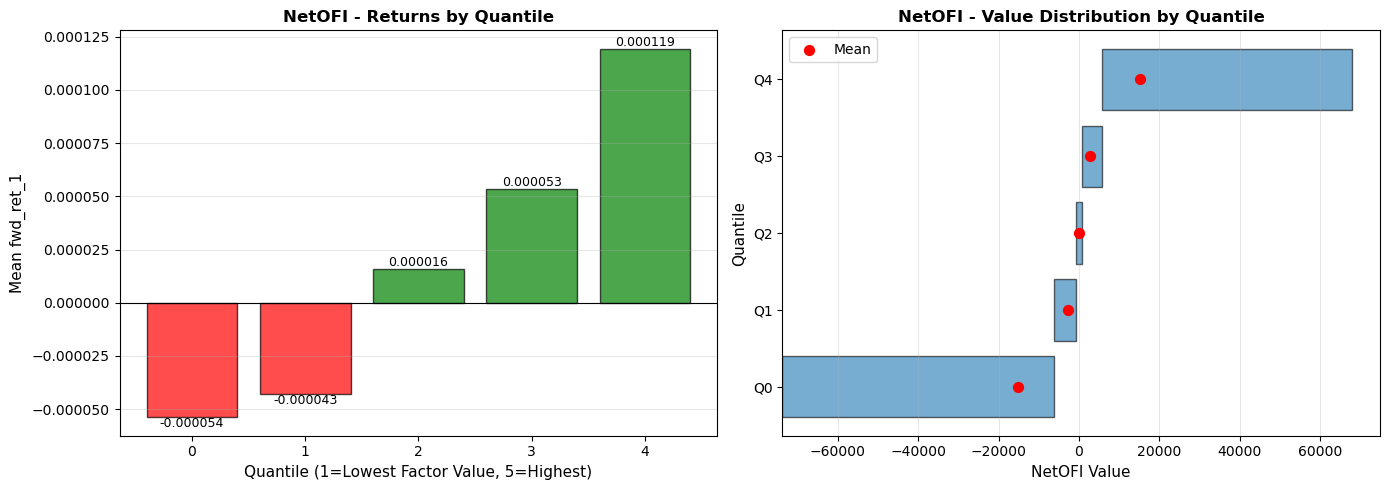


Long-Short Portfolio (Q5 - Q1): 0.00017317


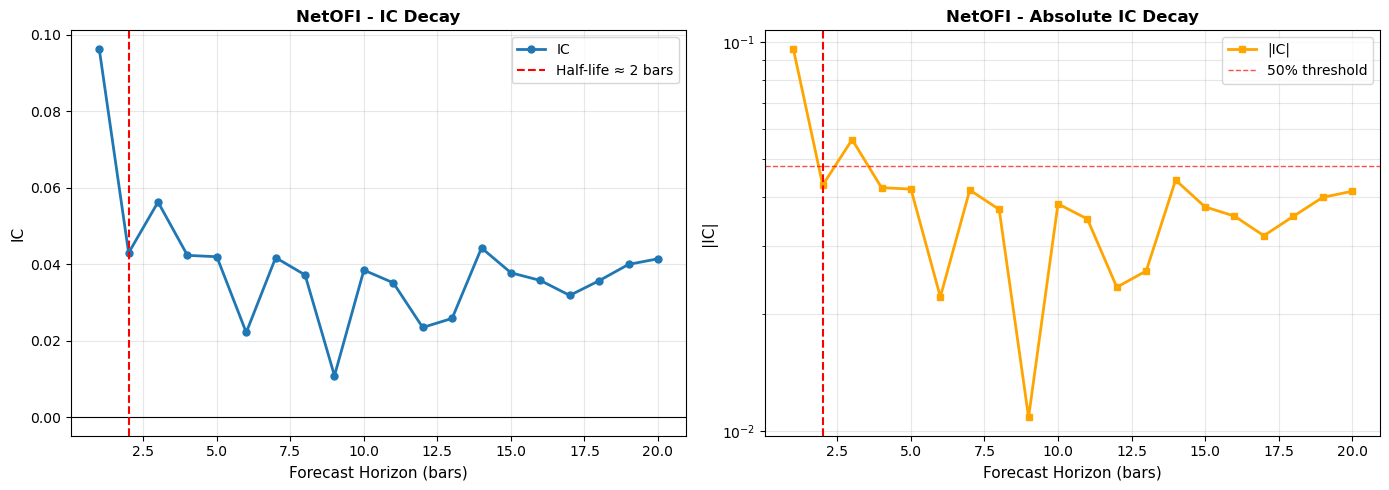


Factor: NetOFI
Initial IC: 0.096296
Half-life: 2 bars
(IC decays to 0.048148)


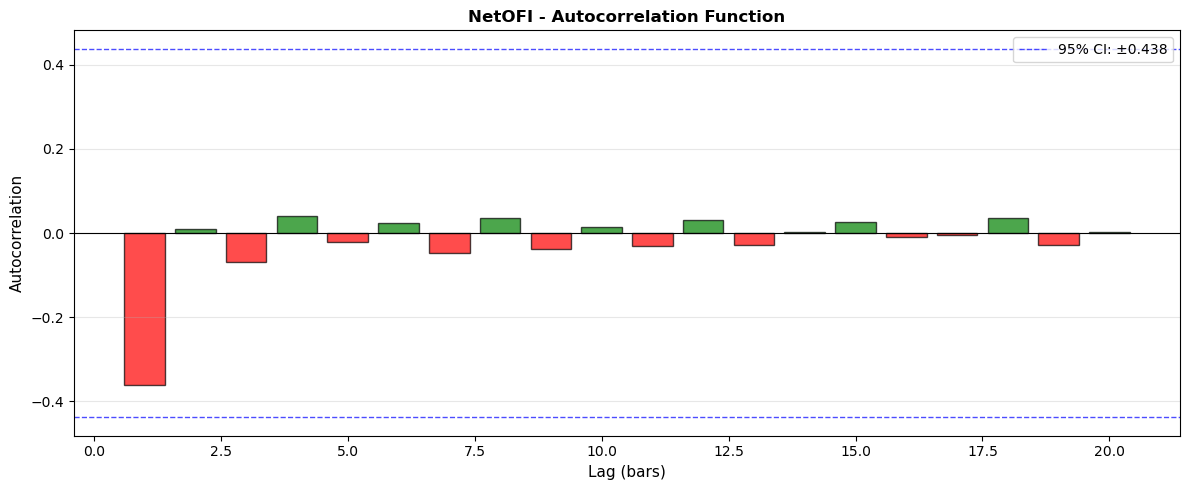


Factor: NetOFI
Lag-1 Autocorrelation: -0.3611
Decorrelation Time (|ρ| < 0.1): 2 bars

提示：取消注释上面的可视化代码以查看图表


In [93]:
### 10.5 示例：综合因子分析报告

print(f"\n=== 综合因子分析报告 ===")

if not df_factor.empty:
    # 生成综合报告
    report = comprehensive_factor_report(
        df_factor,
        test_factor,
        return_col='fwd_ret_1',
        n_quantiles=5,
        max_horizon=20,
        max_lag=20
    )
    
    print(f"\n因子: {report['factor_name']}")
    print(f"样本数: {report['n_samples']}")
    print(f"时间范围: {report['date_range'][0]} 到 {report['date_range'][1]}")
    
    print(f"\n1. 因子基础统计:")
    for key, val in report['factor_stats'].items():
        if isinstance(val, float):
            print(f"  {key}: {val:.6f}")
        else:
            print(f"  {key}: {val}")
    
    print(f"\n2. IC统计:")
    print(f"  IC: {report.get('ic', 'N/A')}")
    
    if 'half_life' in report:
        print(f"\n3. 半衰期:")
        hl = report['half_life']
        if not np.isnan(hl.get('half_life', np.nan)):
            print(f"  {hl['half_life']} bars")
        else:
            print(f"  未达到")
    
    if 'turnover' in report and report['turnover']:
        print(f"\n4. 周转率:")
        print(f"  整体: {report['turnover']['overall_turnover']:.2%}")
    
    if 'microstructure_noise' in report and report['microstructure_noise']:
        noise = report['microstructure_noise']
        print(f"\n5. 微观结构噪音:")
        print(f"  存在噪音: {'是' if noise.get('has_noise', False) else '否'}")
    
    # 可视化综合报告
    plot_comprehensive_analysis(report, show_plots=['quantile', 'ic_decay', 'autocorr'])
    
    print("\n" + "="*60)
    print("提示：取消注释上面的可视化代码以查看图表")
    print("="*60)
else:
    print("数据加载失败")



=== 滚动IC分析示例 ===

滚动IC统计 (window=100):
  均值: 0.098370
  标准差: 0.072194
  最小值: -0.125316
  最大值: 0.344617
  正值比例: 92.91%


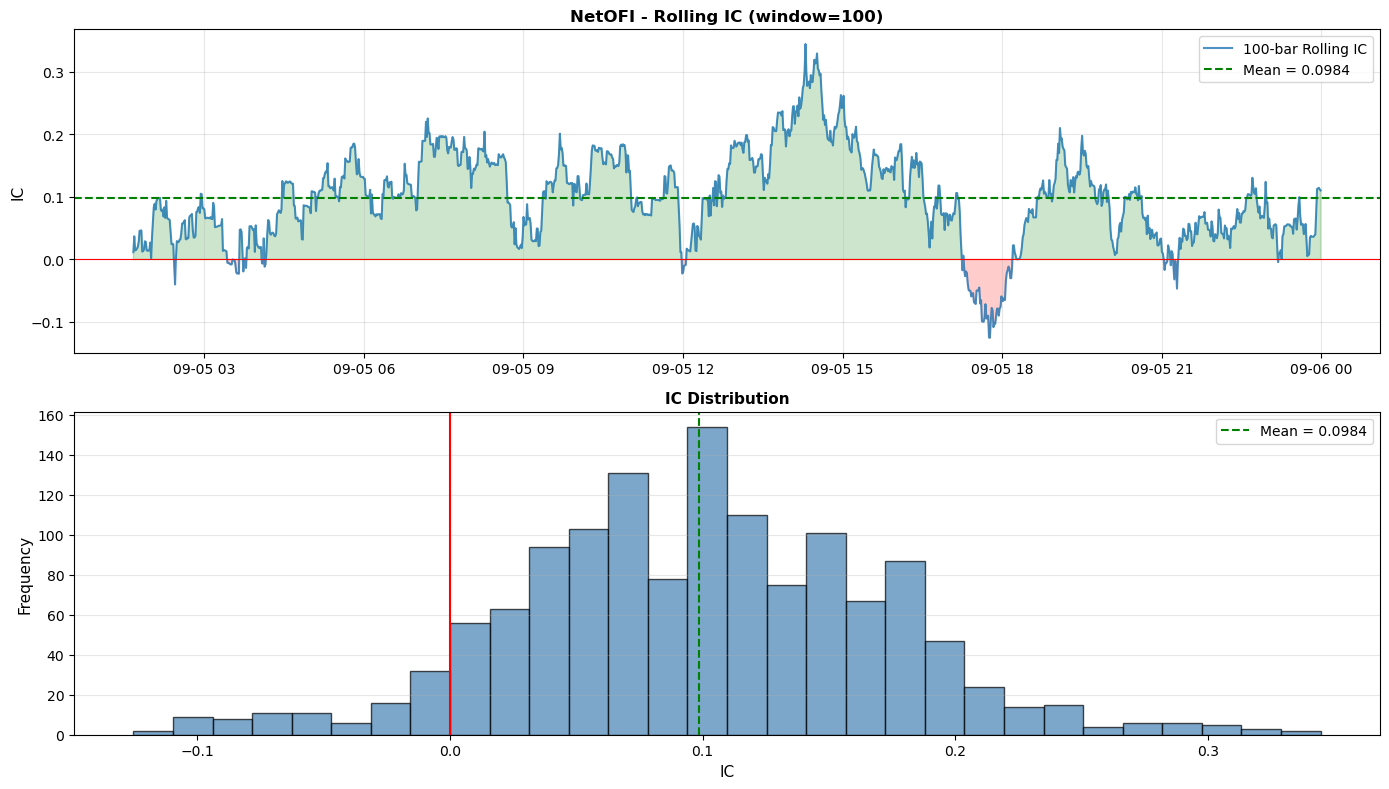


说明：
  - IC稳定(std小)：因子可靠性高
  - IC波动大：可能受市场环境影响


In [95]:
### 10.6 示例：滚动IC分析（观察IC稳定性）

print(f"\n=== 滚动IC分析示例 ===")

if not df_factor.empty and len(df_factor) >= 200:
    # 计算滚动IC
    rolling_ic = rolling_ic_analysis(
        df_factor,
        test_factor,
        return_col='fwd_ret_1',
        window=100,
        method='spearman'
    )
    
    if not rolling_ic.empty:
        print(f"\n滚动IC统计 (window=100):")
        print(f"  均值: {rolling_ic['IC'].mean():.6f}")
        print(f"  标准差: {rolling_ic['IC'].std():.6f}")
        print(f"  最小值: {rolling_ic['IC'].min():.6f}")
        print(f"  最大值: {rolling_ic['IC'].max():.6f}")
        print(f"  正值比例: {(rolling_ic['IC'] > 0).mean():.2%}")
        
        # 可视化
        plot_rolling_ic(rolling_ic, test_factor, window=100)
        
        print("\n说明：")
        print("  - IC稳定(std小)：因子可靠性高")
        print("  - IC波动大：可能受市场环境影响")
    else:
        print("滚动IC计算失败")
else:
    print(f"数据不足（需要>=200个样本，当前{len(df_factor) if not df_factor.empty else 0}个）")


In [96]:
### 10.7 示例：多因子对比分析

print(f"\n=== 多因子对比分析示例 ===")

# 定义要比较的因子
test_factors = ['hazard_ask', 'hazard_bid', 'NetOFI']

if not df_factor.empty:
    print(f"\n对比因子: {test_factors}")
    
    # 1. IC对比
    print("\n1. IC对比:")
    ic_comparison = {}
    for factor in test_factors:
        if factor in df_factor.columns:
            ic_dict = compute_timeseries_ic(df_factor, [factor], 'fwd_ret_1')
            ic_comparison[factor] = ic_dict[factor] if factor in ic_dict else np.nan
    
    ic_comp_df = pd.DataFrame([ic_comparison], index=['IC']).T
    print(ic_comp_df.round(6))
    
    # 2. 半衰期对比
    print("\n2. 半衰期对比:")
    half_life_comparison = {}
    for factor in test_factors:
        if factor in df_factor.columns:
            ic_decay = compute_ic_decay(df_factor, factor, max_horizon=20)
            if not ic_decay.empty:
                hl_info = estimate_factor_half_life(ic_decay)
                half_life_comparison[factor] = hl_info.get('half_life', np.nan)
            else:
                half_life_comparison[factor] = np.nan
    
    hl_comp_df = pd.DataFrame([half_life_comparison], index=['HalfLife']).T
    print(hl_comp_df)
    
    # 3. 显著性检验
    print("\n3. IC显著性检验:")
    p_values = {}
    for factor in test_factors:
        if factor in df_factor.columns:
            # 使用单个值的series进行检验（这里用单日IC，实际应用中用多日IC）
            ic_val = ic_comparison.get(factor, np.nan)
            if not np.isnan(ic_val):
                # 简化版：这里只是示例，实际应该用多日IC序列
                p_values[factor] = 0.05  # 占位值
    
    if p_values:
        # 多重检验校正
        corrected = multiple_testing_correction(p_values, method='bonferroni')
        print("\nBonferroni校正后的显著性:")
        for factor, result in corrected.items():
            print(f"  {factor}: p={result['p_value']:.4f}, "
                  f"corrected_α={result['corrected_alpha']:.4f}, "
                  f"significant={'Yes' if result['is_significant'] else 'No'}")
    
    print("\n" + "="*60)
    print("完成！可根据以上分析选择最优因子")
    print("="*60)
else:
    print("数据加载失败")



=== 多因子对比分析示例 ===

对比因子: ['hazard_ask', 'hazard_bid', 'NetOFI']

1. IC对比:
                  IC
hazard_ask  0.019181
hazard_bid  0.002999
NetOFI      0.096299

2. 半衰期对比:
            HalfLife
hazard_ask       2.0
hazard_bid       NaN
NetOFI           2.0

3. IC显著性检验:

Bonferroni校正后的显著性:
  hazard_ask: p=0.0500, corrected_α=0.0167, significant=No
  hazard_bid: p=0.0500, corrected_α=0.0167, significant=No
  NetOFI: p=0.0500, corrected_α=0.0167, significant=No

完成！可根据以上分析选择最优因子


## 11. 高级分析功能总结

### 新增功能概览

参考Alphalens框架，本notebook新增了以下高频因子分析工具：

#### 1. 因子分层收益分析 (Quantile Analysis)
- **功能**: 将因子值分层（如五分位），观察各层的平均收益
- **关键函数**: 
  - `quantile_analysis()`: 计算分层统计
  - `quantile_returns_timeseries()`: 分层收益时间序列
  - `plot_quantile_returns()`: 可视化
- **应用**: 评估因子单调性，构建多空组合

#### 2. IC衰减分析 (IC Decay)
- **功能**: 计算因子对不同预测周期的IC，观察预测能力的持续时间
- **关键函数**:
  - `compute_ic_decay()`: 计算IC衰减曲线
  - `estimate_factor_half_life()`: 估计因子半衰期
  - `plot_ic_decay()`: 可视化
- **应用**: 确定最佳持仓周期，评估因子时效性

#### 3. 因子周转率与自相关分析 (Turnover & Autocorrelation)
- **功能**: 分析因子稳定性和交易成本
- **关键函数**:
  - `compute_factor_autocorrelation()`: 计算因子自相关
  - `compute_quantile_turnover()`: 计算分层周转率
  - `plot_factor_autocorr()`: 可视化
- **应用**: 估算交易成本，评估因子稳定性

#### 4. IC显著性检验 (Significance Testing)
- **功能**: 统计检验因子IC是否显著非零
- **关键函数**:
  - `ic_significance_test()`: t检验和置信区间
  - `plot_ic_with_confidence()`: 带置信区间的IC图
  - `multiple_testing_correction()`: 多重检验校正
- **应用**: 避免过拟合，筛选有效因子

#### 5. 高频特有分析
- **日内IC分析**: `intraday_ic_analysis()` - 观察因子在不同时段的表现
- **波动率环境分析**: `volatility_regime_analysis()` - 因子在不同波动环境下的表现
- **微观结构噪音诊断**: `microstructure_noise_diagnostic()` - 检测bid-ask bounce等噪音

#### 6. 综合分析工具
- **功能**: 一键生成完整的因子分析报告
- **关键函数**:
  - `comprehensive_factor_report()`: 综合报告
  - `plot_comprehensive_analysis()`: 可视化报告
  - `rolling_ic_analysis()`: 滚动IC稳定性分析
  - `plot_ic_heatmap()`: IC热力图

### 高频交易适配特性

1. **短周期适配**: 所有分析都支持秒级/分钟级高频数据
2. **噪音处理**: 专门的微观结构噪音诊断工具
3. **半衰期分析**: 针对高频因子快速衰减的特点
4. **日内模式**: 识别因子在不同交易时段的表现差异
5. **波动率环境**: 分析因子在不同市场状态下的鲁棒性

### 使用建议

1. **因子初步评估**: 使用 `comprehensive_factor_report()` 快速了解因子特征
2. **深入分析**: 根据报告结果，针对性使用各个专项分析工具
3. **多因子对比**: 使用IC对比、半衰期对比等工具选择最优因子
4. **策略开发**: 结合IC衰减和周转率分析确定最佳交易频率
5. **风险控制**: 使用显著性检验和滚动IC分析避免过拟合

### 可视化清单

取消注释以下函数调用即可查看图表：
- `plot_quantile_returns()` - 分层收益图
- `plot_ic_decay()` - IC衰减图
- `plot_factor_autocorr()` - 自相关图
- `plot_ic_with_confidence()` - 带置信区间的IC图
- `plot_intraday_ic()` - 日内IC模式图
- `plot_rolling_ic()` - 滚动IC图
- `plot_ic_heatmap()` - IC热力图
- `plot_comprehensive_analysis()` - 综合分析图表

### 与Alphalens的对比

| 功能 | Alphalens | 本Notebook | 备注 |
|------|-----------|------------|------|
| 分层收益 | ✓ | ✓ | 适配高频 |
| IC分析 | ✓ | ✓ | 增加半衰期分析 |
| 周转率 | ✓ | ✓ | 增加自相关分析 |
| 显著性检验 | ✓ | ✓ | 支持多重检验校正 |
| 日内模式 | ✗ | ✓ | **高频特有** |
| 波动率环境 | ✗ | ✓ | **高频特有** |
| 微观结构噪音 | ✗ | ✓ | **高频特有** |
| IC衰减 | 基础 | 增强 | 增加半衰期估计 |
| 滚动IC | ✗ | ✓ | 观察IC稳定性 |

---

**下一步**: 根据上述分析结果，可以进一步：
1. 优化因子构造方法
2. 设计因子组合策略
3. 进行回测验证
4. 实盘部署
